# Kvalitet podataka kroz validaciju i oporavak

Ovaj notebook predstavlja objedinjeni praktični rad o kvalitetu podataka nad dva različita skupa podataka: `Cafe Sales` i `Credit Risk`.

Rad prikazuje kako se sistematskim auditom, validacijom, oporavkom i označavanjem problematičnih zapisa povećava pouzdanost analize. Modeli mašinskog učenja koriste se u završnom delu kao praktična demonstracija uticaja kvaliteta podataka na automatizovane odluke.


## Ideja rada

U radu se koriste dva dataseta zato što prikazuju dve različite uloge kvaliteta podataka.

**Cafe Sales** predstavlja scenario u kome se deo podataka može oporaviti:

> Podatke možemo delimično oporaviti jer postoje aritmetička i poslovna pravila.

U ovom skupu postoje transakcioni podaci sa oštećenim vrednostima, kao što su `ERROR`, `UNKNOWN` i nedostajuće vrednosti. Pošto postoje odnosi između artikla, cene, količine i ukupnog iznosa, deo podataka može da se oporavi pomoću jasno definisanih pravila.

**Credit Risk** predstavlja scenario u kome je naglasak na validaciji i kontroli uticaja podataka:

> Problematične vrednosti možemo validirati, označiti i kontrolisati njihov uticaj na model.

U ovom skupu fokus je na validaciji, detekciji nelogičnosti, označavanju rizičnih zapisa i proceni uticaja kvaliteta podataka na klasifikacioni model.


## Uloge datasetova

| Dataset | Glavni fokus | Šta se pokazuje |
|---|---|---|
| Cafe Sales | Oporavak podataka | Kada postoje domenska i aritmetička pravila, deo oštećenih vrednosti može se pouzdano rekonstruisati. |
| Credit Risk | Validacija i uticaj na model | Problematične vrednosti se validiraju, označavaju i uključuju u procenu uticaja kvaliteta podataka na model. |


In [124]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="ticks")

RANDOM_STATE = 42


In [ ]:
DATA_DIR = Path(".")

CAFE_SALES_PATH = DATA_DIR / "cafe-sales-dataset.csv"
CREDIT_RISK_PATH = DATA_DIR / "credit-risk-dataset.csv"

CAFE_SALES_PATH, CREDIT_RISK_PATH

(PosixPath('cafe_sales.csv'), PosixPath('credit-risk-dataset.csv'))

In [126]:
cafe_raw = pd.read_csv(CAFE_SALES_PATH)
credit_raw = pd.read_csv(CREDIT_RISK_PATH)

print("Cafe Sales shape:", cafe_raw.shape)
print("Credit Risk shape:", credit_raw.shape)

Cafe Sales shape: (10000, 9)
Credit Risk shape: (32581, 12)


In [127]:
display(cafe_raw.head())
display(credit_raw.head())

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Receipt Modifier
0,TXN_1961373,Coffee,2,2.0,3.60,Credit Card,Takeaway,2023-09-08,loyalty_discount
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,none
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19,none
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,none
4,TXN_3160411,Coffee,2,2.0,3.40,Digital Wallet,In-store,2023-06-11,combo_discount


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 1. Osnovni audit kvaliteta podataka

Prvi korak je zajednički audit oba skupa. Cilj ovog dela je da se pre bilo kakvog čišćenja ili modeliranja dobije pregled strukture podataka: broj redova i kolona, tipovi atributa, nedostajuće vrednosti, duplikati, broj jedinstvenih vrednosti i osnovna uloga svake kolone.

Ovaj pristup prati obrazac iz referentnog projekta: najpre se pravi tabela audita, zatim se iz nje izvode zaključci o tome koje kolone su identifikatori, koje su kandidati za vremenske atribute, koje predstavljaju target, a koje ulaze u dalju analizu.


In [128]:
def dataset_overview(frame, dataset_name):
    return pd.DataFrame({
        "dataset": [dataset_name],
        "rows": [len(frame)],
        "columns": [frame.shape[1]],
        "duplicated_rows": [frame.duplicated().sum()],
        "total_missing": [frame.isna().sum().sum()],
        "missing_cells_pct": [round(frame.isna().mean().mean() * 100, 2)],
    })


def infer_feature_role(column_name, target_columns, identifier_keywords=("id",)):
    lower_name = column_name.lower()
    if column_name in target_columns:
        return "target"
    if any(keyword in lower_name for keyword in identifier_keywords):
        return "identifier"
    if any(keyword in lower_name for keyword in ["date", "day", "time"]):
        return "datetime_candidate"
    return "predictor"


def feature_audit_table(frame, dataset_name, target_columns):
    audit = pd.DataFrame({
        "dataset": dataset_name,
        "feature": frame.columns,
        "dtype": frame.dtypes.astype(str).values,
        "missing": frame.isna().sum().values,
        "missing_pct": (frame.isna().mean() * 100).round(2).values,
        "unique": frame.nunique(dropna=False).values,
    })

    variances = []
    for column in frame.columns:
        if pd.api.types.is_numeric_dtype(frame[column]):
            variances.append(frame[column].var())
        else:
            variances.append(np.nan)

    audit["variance"] = variances
    audit["role"] = audit["feature"].apply(
        lambda column: infer_feature_role(column, target_columns=target_columns)
    )

    return audit.sort_values(["role", "missing_pct", "feature"], ascending=[True, False, True]).reset_index(drop=True)


In [129]:
overview = pd.concat(
    [
        dataset_overview(cafe_raw, "Cafe Sales"),
        dataset_overview(credit_raw, "Credit Risk"),
    ],
    ignore_index=True,
)

display(overview)


,dataset,rows,columns,duplicated_rows,total_missing,missing_cells_pct
0,Cafe Sales,10000,9,0,6826,7.58
1,Credit Risk,32581,12,165,4011,1.03


In [130]:
cafe_audit = feature_audit_table(
    cafe_raw,
    dataset_name="Cafe Sales",
    target_columns=[],
)

credit_audit = feature_audit_table(
    credit_raw,
    dataset_name="Credit Risk",
    target_columns=["loan_status"],
)

display(cafe_audit)
display(credit_audit)


,dataset,feature,dtype,missing,missing_pct,unique,variance,role
0,Cafe Sales,Transaction Date,str,159,1.59,368,NaN,datetime_candidate
1,Cafe Sales,Transaction ID,str,0,0.00,10000,NaN,identifier
2,Cafe Sales,Location,str,3265,32.65,5,NaN,predictor
3,Cafe Sales,Payment Method,str,2579,25.79,6,NaN,predictor
4,Cafe Sales,Item,str,333,3.33,11,NaN,predictor
5,Cafe Sales,Price Per Unit,str,179,1.79,9,NaN,predictor
6,Cafe Sales,Total Spent,str,173,1.73,88,NaN,predictor
7,Cafe Sales,Quantity,str,138,1.38,8,NaN,predictor
8,Cafe Sales,Receipt Modifier,str,0,0.00,5,NaN,predictor


,dataset,feature,dtype,missing,missing_pct,unique,variance,role
0,Credit Risk,loan_int_rate,float64,3116,9.56,349,1.050058e+01,predictor
1,Credit Risk,person_emp_length,float64,895,2.75,37,1.716138e+01,predictor
2,Credit Risk,cb_person_cred_hist_length,int64,0,0.00,29,1.644303e+01,predictor
3,Credit Risk,cb_person_default_on_file,str,0,0.00,2,NaN,predictor
4,Credit Risk,loan_amnt,int64,0,0.00,753,3.996878e+07,predictor
5,Credit Risk,loan_grade,str,0,0.00,7,NaN,predictor
6,Credit Risk,loan_intent,str,0,0.00,6,NaN,predictor
7,Credit Risk,loan_percent_income,float64,0,0.00,77,1.140234e-02,predictor
8,Credit Risk,person_age,int64,0,0.00,58,4.029810e+01,predictor
9,Credit Risk,person_home_ownership,str,0,0.00,4,NaN,predictor


In [131]:
audit_summary = pd.DataFrame({
    "dataset": ["Cafe Sales", "Credit Risk"],
    "columns_with_missing": [
        int((cafe_raw.isna().sum() > 0).sum()),
        int((credit_raw.isna().sum() > 0).sum()),
    ],
    "max_missing_pct": [
        round(cafe_raw.isna().mean().max() * 100, 2),
        round(credit_raw.isna().mean().max() * 100, 2),
    ],
    "identifier_columns": [
        ", ".join(cafe_audit.loc[cafe_audit["role"] == "identifier", "feature"]),
        ", ".join(credit_audit.loc[credit_audit["role"] == "identifier", "feature"]),
    ],
    "target_columns": [
        ", ".join(cafe_audit.loc[cafe_audit["role"] == "target", "feature"]),
        ", ".join(credit_audit.loc[credit_audit["role"] == "target", "feature"]),
    ],
})

display(audit_summary)


,dataset,columns_with_missing,max_missing_pct,identifier_columns,target_columns
0,Cafe Sales,7,32.65,Transaction ID,
1,Credit Risk,2,9.56,,loan_status


### Nalazi iz osnovnog audita

Početni audit pokazuje da se skupovi razlikuju po tipu problema. `Cafe Sales` ima veći broj eksplicitno oštećenih ili nedostajućih vrednosti u transakcionim kolonama, dok `Credit Risk` ima manji broj kolona sa nedostajućim vrednostima, ali sadrži atribute koji zahtevaju dodatnu logičku i poslovnu validaciju.

Ovakva razlika određuje dalji tok rada. Kod `Cafe Sales` naglasak će biti na oporavku vrednosti pomoću pravila, dok će kod `Credit Risk` naglasak biti na validaciji, označavanju problematičnih zapisa i kontroli njihovog uticaja na model.


## 2. Cafe Sales: formalna popunjenost i stvarna upotrebljivost

Kod transakcionih podataka provera `NaN` vrednosti predstavlja samo početni nivo audita. Vrednosti kao što su `ERROR` i `UNKNOWN` formalno popunjavaju ćeliju, ali ne predstavljaju pouzdanu informaciju za analizu.

Zbog toga se za `Cafe Sales` uvodi razlika između:

- **formalno popunjene vrednosti**: ćelija nije prazna,
- **upotrebljive vrednosti**: vrednost ima značenje, ispravan tip i može se koristiti u daljoj analizi.

Ovaj korak je važan jer se deo kasnijeg oporavka zasniva upravo na kolonama koje su stvarno upotrebljive.


In [132]:
INVALID_TOKENS = {"ERROR", "UNKNOWN"}
CAFE_TEXT_COLUMNS = [
    "Item",
    "Quantity",
    "Price Per Unit",
    "Total Spent",
    "Payment Method",
    "Location",
    "Transaction Date",
]


def normalize_cafe_tokens(frame):
    df = frame.copy()
    for column in CAFE_TEXT_COLUMNS:
        df[column] = df[column].replace(list(INVALID_TOKENS), np.nan)
    return df


def build_cafe_typed_view(frame):
    df = frame.copy()
    df["Quantity_num"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["Price_num"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
    df["Total_num"] = pd.to_numeric(df["Total Spent"], errors="coerce")
    df["TransactionDate_dt"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
    return df


def cafe_quality_scorecard(frame):
    rows = {
        "Item": frame["Item"].notna().sum(),
        "Quantity": frame["Quantity_num"].notna().sum(),
        "Price Per Unit": frame["Price_num"].notna().sum(),
        "Total Spent": frame["Total_num"].notna().sum(),
        "Payment Method": frame["Payment Method"].notna().sum(),
        "Location": frame["Location"].notna().sum(),
        "Transaction Date": frame["TransactionDate_dt"].notna().sum(),
        "Receipt Modifier": frame["Receipt Modifier"].notna().sum(),
    }
    scorecard = pd.DataFrame.from_dict(rows, orient="index", columns=["usable_values"])
    scorecard["usable_pct"] = (scorecard["usable_values"] / len(frame) * 100).round(2)
    scorecard["unusable_values"] = len(frame) - scorecard["usable_values"]
    return scorecard.sort_values("usable_pct")


In [133]:
cafe_normalized = normalize_cafe_tokens(cafe_raw)
cafe_typed = build_cafe_typed_view(cafe_normalized)

cafe_scorecard_initial = cafe_quality_scorecard(cafe_typed)
display(cafe_scorecard_initial)


,usable_values,usable_pct,unusable_values
Location,6039,60.39,3961
Payment Method,6822,68.22,3178
Item,9031,90.31,969
Price Per Unit,9467,94.67,533
Total Spent,9498,94.98,502
Quantity,9521,95.21,479
Transaction Date,9540,95.40,460
Receipt Modifier,10000,100.00,0


In [134]:
cafe_issue_matrix = pd.DataFrame(index=cafe_raw.columns)
cafe_issue_matrix["missing_na"] = cafe_raw.isna().sum()
cafe_issue_matrix["error_token"] = cafe_raw.eq("ERROR").sum(numeric_only=False)
cafe_issue_matrix["unknown_token"] = cafe_raw.eq("UNKNOWN").sum(numeric_only=False)
cafe_issue_matrix["total_problematic"] = cafe_issue_matrix[["missing_na", "error_token", "unknown_token"]].sum(axis=1)
cafe_issue_matrix["problematic_pct"] = (cafe_issue_matrix["total_problematic"] / len(cafe_raw) * 100).round(2)

cafe_issue_matrix.sort_values("problematic_pct", ascending=False)


,missing_na,error_token,unknown_token,total_problematic,problematic_pct
Location,3265,358,338,3961,39.61
Payment Method,2579,306,293,3178,31.78
Item,333,292,344,969,9.69
Price Per Unit,179,190,164,533,5.33
Total Spent,173,164,165,502,5.02
Quantity,138,170,171,479,4.79
Transaction Date,159,142,159,460,4.60
Transaction ID,0,0,0,0,0.00
Receipt Modifier,0,0,0,0,0.00


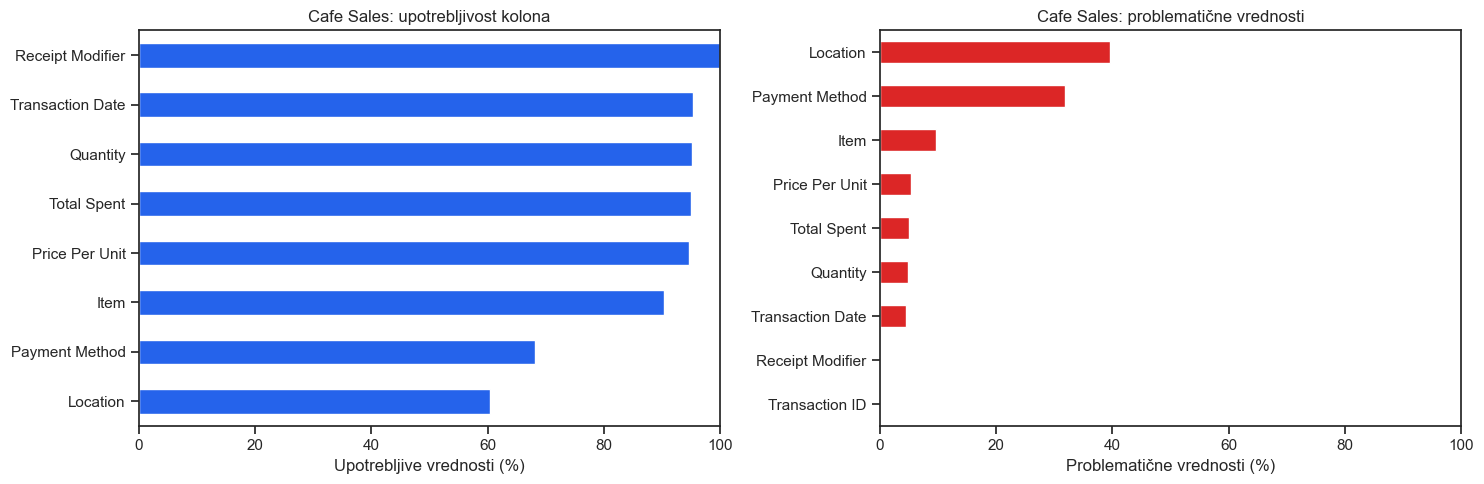

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cafe_scorecard_initial["usable_pct"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#2563eb",
)
axes[0].set_title("Cafe Sales: upotrebljivost kolona")
axes[0].set_xlabel("Upotrebljive vrednosti (%)")
axes[0].set_xlim(0, 100)

cafe_issue_matrix["problematic_pct"].sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#dc2626",
)
axes[1].set_title("Cafe Sales: problematične vrednosti")
axes[1].set_xlabel("Problematične vrednosti (%)")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()


### Šta ovaj pregled znači za dalju obradu

Kod `Cafe Sales` postoji značajna razlika između formalne popunjenosti i stvarne upotrebljivosti podataka. Za oporavak su posebno važne transakcione kolone `Item`, `Quantity`, `Price Per Unit` i `Total Spent`, jer se njihove vrednosti mogu međusobno proveravati.

`Quantity`, `Price Per Unit` i `Total Spent` čine povezanu celinu: ukupan iznos zavisi od količine, cene i eventualne izmene računa. Zbog toga se u nastavku uvodi cenovnik izveden iz validnih redova i pravila za kontrolisani oporavak podataka.


## 3. Cafe Sales: osnova za oporavak podataka

Oporavak podataka se uvodi nakon početnog audita, jer audit pokazuje dve važne stvari. Prvo, deo vrednosti u kolonama `Quantity`, `Price Per Unit` i `Total Spent` ima ograničenu upotrebljivost. Drugo, te kolone čine povezanu transakcionu strukturu: ukupan iznos transakcije zavisi od količine i jedinične cene.

Oporavak se zato zasniva na proverljivim odnosima u samom datasetu:

- isti artikal bi trebalo da ima stabilnu osnovnu cenu,
- ukupan iznos je povezan sa količinom i cenom,
- `Receipt Modifier` može objasniti deo odstupanja od osnovnog pravila.

Pre oporavka je zato potrebno prvo izvesti cenovnik iz validnih redova i proveriti koliko su pravila stabilna.


In [136]:
valid_price_rows = cafe_typed.dropna(subset=["Item", "Price_num"]).copy()

menu_prices = (
    valid_price_rows
    .groupby("Item")["Price_num"]
    .agg(lambda prices: prices.mode().iloc[0])
    .to_dict()
)

price_check = (
    valid_price_rows
    .assign(derived_price=valid_price_rows["Item"].map(menu_prices))
    .groupby("Item")
    .agg(
        derived_price=("derived_price", "first"),
        valid_rows_for_item=("Price_num", "size"),
        rows_with_derived_price=("Price_num", lambda prices: (prices == prices.mode().iloc[0]).sum()),
        observed_prices=("Price_num", lambda prices: sorted(prices.dropna().unique().tolist())),
    )
)

price_check["price_stability_pct"] = (
    price_check["rows_with_derived_price"] / price_check["valid_rows_for_item"] * 100
).round(2)

price_check.reset_index().sort_values("Item")


,Item,derived_price,valid_rows_for_item,rows_with_derived_price,observed_prices,price_stability_pct
0,Cake,3.0,1085,1085,[3.0],100.0
1,Coffee,2.0,1108,1108,[2.0],100.0
2,Cookie,1.0,1026,1026,[1.0],100.0
3,Juice,3.0,1110,1110,[3.0],100.0
4,Salad,5.0,1082,1082,[5.0],100.0
5,Sandwich,4.0,1082,1082,[4.0],100.0
6,Smoothie,4.0,1036,1036,[4.0],100.0
7,Tea,1.5,1023,1023,[1.5],100.0


In [137]:
cafe_rules = cafe_typed.copy()
cafe_rules["expected_price"] = cafe_rules["Item"].map(menu_prices)
cafe_rules["expected_total"] = cafe_rules["Quantity_num"] * cafe_rules["Price_num"]
cafe_rules["receipt_modified"] = cafe_rules["Receipt Modifier"].fillna("none").ne("none")

cafe_rules["flag_price_missing"] = cafe_rules["Price_num"].isna()
cafe_rules["flag_quantity_missing"] = cafe_rules["Quantity_num"].isna()
cafe_rules["flag_total_missing"] = cafe_rules["Total_num"].isna()

cafe_rules["flag_price_conflict"] = (
    cafe_rules["Item"].isin(menu_prices.keys())
    & cafe_rules["Price_num"].notna()
    & cafe_rules["expected_price"].notna()
    & (cafe_rules["Price_num"] != cafe_rules["expected_price"])
)

cafe_rules["flag_total_conflict"] = (
    cafe_rules["Quantity_num"].notna()
    & cafe_rules["Price_num"].notna()
    & cafe_rules["Total_num"].notna()
    & (~np.isclose(cafe_rules["Total_num"], cafe_rules["expected_total"]))
)

cafe_rules["flag_unexplained_total_conflict"] = (
    cafe_rules["flag_total_conflict"]
    & (~cafe_rules["receipt_modified"])
)

rule_summary = pd.DataFrame({
    "affected_rows": {
        "missing quantity": int(cafe_rules["flag_quantity_missing"].sum()),
        "missing price": int(cafe_rules["flag_price_missing"].sum()),
        "missing total": int(cafe_rules["flag_total_missing"].sum()),
        "price conflicts": int(cafe_rules["flag_price_conflict"].sum()),
        "total conflicts": int(cafe_rules["flag_total_conflict"].sum()),
        "unexplained total conflicts": int(cafe_rules["flag_unexplained_total_conflict"].sum()),
    }
})
rule_summary["share_of_dataset_pct"] = (rule_summary["affected_rows"] / len(cafe_rules) * 100).round(2)
rule_summary.sort_values("affected_rows", ascending=False)


,affected_rows,share_of_dataset_pct
total conflicts,3272,32.72
missing price,533,5.33
missing total,502,5.02
missing quantity,479,4.79
price conflicts,0,0.00
unexplained total conflicts,0,0.00


In [138]:
decision_table = pd.DataFrame([
    {
        "nalaz": "Cena artikla može da se izvede iz validnih redova.",
        "odluka_za_obradu": "Izvedeni cenovnik koristi se kao osnova za proveru i oporavak cene.",
    },
    {
        "nalaz": "Količina, cena i ukupan iznos su povezani aritmetičkim pravilom.",
        "odluka_za_obradu": "Kada su dve vrednosti pouzdane, treća može da se izračuna.",
    },
    {
        "nalaz": "`Receipt Modifier` može objasniti odstupanje ukupnog iznosa.",
        "odluka_za_obradu": "Odstupanje se tumači kroz dominantni faktor izmene računa.",
    },
])

display(decision_table)


,nalaz,odluka_za_obradu
0,Cena artikla može da se izvede iz validnih red...,Izvedeni cenovnik koristi se kao osnova za pro...
1,"Količina, cena i ukupan iznos su povezani arit...","Kada su dve vrednosti pouzdane, treća može da ..."
2,`Receipt Modifier` može objasniti odstupanje u...,Odstupanje se tumači kroz dominantni faktor iz...


### Implikacije za oporavak

Ovaj korak daje osnovu za kontrolisani oporavak podataka. Vrednosti se popravljaju samo kada postoji jasno pravilo i dovoljno pouzdanih informacija u istom zapisu ili u izvedenom cenovniku. Time se izbegava nekritičko popunjavanje podataka koje bi povećalo kompletnost, ali smanjilo poverenje u rezultate analize.


## 4. Cafe Sales: kontrolisani oporavak transakcionih vrednosti

U ovoj fazi se primenjuju pravila koja imaju jasnu osnovu u podacima. Oporavak se ograničava na transakcione vrednosti kod kojih postoji proverljiva veza: artikal, količina, jedinična cena i ukupan iznos.

Svaka izmena se evidentira u `repair_log` tabeli. Na taj način se razlikuje stvarno oporavljena vrednost od vrednosti koja je ostala nepoznata.


In [139]:
modifier_rows = cafe_typed.dropna(subset=["Quantity_num", "Price_num", "Total_num"]).copy()
modifier_rows = modifier_rows[(modifier_rows["Quantity_num"] * modifier_rows["Price_num"]) > 0]
modifier_rows["modifier_factor"] = (
    modifier_rows["Total_num"] / (modifier_rows["Quantity_num"] * modifier_rows["Price_num"])
).round(4)

modifier_factors = (
    modifier_rows
    .groupby("Receipt Modifier")["modifier_factor"]
    .agg(lambda factors: factors.mode().iloc[0])
    .to_dict()
)

modifier_check = (
    modifier_rows
    .assign(expected_factor=modifier_rows["Receipt Modifier"].map(modifier_factors))
    .groupby("Receipt Modifier")
    .agg(
        derived_factor=("expected_factor", "first"),
        valid_rows=("modifier_factor", "size"),
        rows_with_derived_factor=("modifier_factor", lambda factors: (factors == factors.mode().iloc[0]).sum()),
        observed_factors=("modifier_factor", lambda factors: sorted(factors.dropna().unique().tolist())),
    )
)
modifier_check["factor_stability_pct"] = (
    modifier_check["rows_with_derived_factor"] / modifier_check["valid_rows"] * 100
).round(2)

modifier_check.reset_index().sort_values("Receipt Modifier")


,Receipt Modifier,derived_factor,valid_rows,rows_with_derived_factor,observed_factors,factor_stability_pct
0,combo_discount,0.85,684,553,"[0.8467, 0.8489, 0.85, 0.8507, 1.0]",80.85
1,loyalty_discount,0.90,1237,1136,"[0.9, 1.0]",91.84
2,none,1.00,4920,4920,[1.0],100.00
3,rush_hour_markup,1.15,698,577,"[1.0, 1.1467, 1.1489, 1.1493, 1.15]",82.66
4,service_fee,1.10,1005,904,"[1.0, 1.1]",89.95


In [140]:
MAX_REASONABLE_QUANTITY = 100

cafe_recovered = cafe_typed.copy()
cafe_recovered["expected_price"] = cafe_recovered["Item"].map(menu_prices)
cafe_recovered["modifier_factor"] = cafe_recovered["Receipt Modifier"].map(modifier_factors).fillna(1.0)
repair_log = {}

# Price_num = menu price for known item
mask = cafe_recovered["Price_num"].isna() & cafe_recovered["expected_price"].notna()
repair_log["price_from_item"] = int(mask.sum())
cafe_recovered.loc[mask, "Price_num"] = cafe_recovered.loc[mask, "expected_price"]

# Total_num = Quantity_num * Price_num * modifier_factor
mask = (
    cafe_recovered["Total_num"].isna()
    & cafe_recovered["Quantity_num"].notna()
    & cafe_recovered["Price_num"].notna()
    & cafe_recovered["modifier_factor"].notna()
)
repair_log["total_from_quantity_price_modifier"] = int(mask.sum())
cafe_recovered.loc[mask, "Total_num"] = (
    cafe_recovered.loc[mask, "Quantity_num"]
    * cafe_recovered.loc[mask, "Price_num"]
    * cafe_recovered.loc[mask, "modifier_factor"]
).round(2)

# Quantity_num = Total_num / (Price_num * modifier_factor)
mask = (
    cafe_recovered["Quantity_num"].isna()
    & cafe_recovered["Total_num"].notna()
    & cafe_recovered["Price_num"].notna()
    & cafe_recovered["modifier_factor"].notna()
    & (cafe_recovered["Price_num"] * cafe_recovered["modifier_factor"] > 0)
)
ratio = cafe_recovered.loc[mask, "Total_num"] / (
    cafe_recovered.loc[mask, "Price_num"] * cafe_recovered.loc[mask, "modifier_factor"]
)
valid_ratio = np.isclose(ratio, ratio.round()) & ratio.between(1, MAX_REASONABLE_QUANTITY)
repair_log["quantity_from_total_price_modifier"] = int(valid_ratio.sum())
cafe_recovered.loc[ratio.index[valid_ratio], "Quantity_num"] = ratio[valid_ratio].round()

# Item = unique item for known price
price_to_items = {}
for item, price in menu_prices.items():
    price_to_items.setdefault(price, []).append(item)

repair_log["item_from_unique_price"] = 0
mask = cafe_recovered["Item"].isna() & cafe_recovered["Price_num"].notna()
for price, items in price_to_items.items():
    if len(items) == 1:
        unique_mask = mask & (cafe_recovered["Price_num"] == price)
        repair_log["item_from_unique_price"] += int(unique_mask.sum())
        cafe_recovered.loc[unique_mask, "Item"] = items[0]

repair_log


{'price_from_item': 479,
 'total_from_quantity_price_modifier': 479,
 'quantity_from_total_price_modifier': 270,
 'item_from_unique_price': 468}

In [141]:
transaction_quality_before = cafe_quality_scorecard(cafe_typed).loc[
    ["Item", "Quantity", "Price Per Unit", "Total Spent"]
]
transaction_quality_after = cafe_quality_scorecard(cafe_recovered).loc[
    ["Item", "Quantity", "Price Per Unit", "Total Spent"]
]

recovery_table = pd.DataFrame.from_dict(repair_log, orient="index", columns=["recovered_rows"])
recovery_table["share_of_dataset_pct"] = (recovery_table["recovered_rows"] / len(cafe_recovered) * 100).round(2)

display(recovery_table.sort_values("recovered_rows", ascending=False))

quality_comparison = transaction_quality_before[["usable_pct"]].join(
    transaction_quality_after[["usable_pct"]],
    lsuffix="_before",
    rsuffix="_after",
)
quality_comparison["gain_pct_points"] = (
    quality_comparison["usable_pct_after"] - quality_comparison["usable_pct_before"]
).round(2)

display(quality_comparison)


,recovered_rows,share_of_dataset_pct
price_from_item,479,4.79
total_from_quantity_price_modifier,479,4.79
item_from_unique_price,468,4.68
quantity_from_total_price_modifier,270,2.70


,usable_pct_before,usable_pct_after,gain_pct_points
Item,90.31,94.99,4.68
Quantity,95.21,97.91,2.70
Price Per Unit,94.67,99.46,4.79
Total Spent,94.98,99.77,4.79


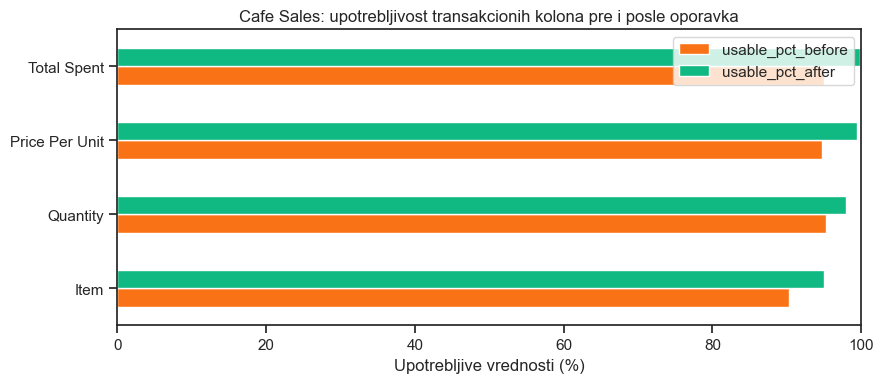

In [142]:
quality_comparison[["usable_pct_before", "usable_pct_after"]].plot(
    kind="barh",
    figsize=(9, 4),
    color=["#f97316", "#10b981"],
)
plt.title("Cafe Sales: upotrebljivost transakcionih kolona pre i posle oporavka")
plt.xlabel("Upotrebljive vrednosti (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


### Efekat oporavka na upotrebljivost podataka

Oporavak povećava upotrebljivost transakcionih kolona uz jasno definisana pravila popunjavanja. Početna upotrebljivost ovih kolona bila je relativno visoka, pa se efekat oporavka vidi kroz ciljano vraćanje konkretnih oštećenih zapisa.

Najvažnije je da svako pravilo ima jasnu osnovu: cena se izvodi iz stabilnog cenovnika, ukupan iznos se računa uz faktor izmene računa, a količina se oporavlja kada rezultat ostaje ceo broj u razumnom opsegu.

Ovakav pristup čuva granicu između oporavljenih podataka i podataka koji ostaju nepouzdani. Time se povećava korisnost skupa za dalju analizu, uz očuvano poreklo svake izmene.


## 5. Cafe Sales: sloj pouzdanosti zapisa

Posle oporavka se pored procenta popunjenih vrednosti posmatra i pouzdanost pojedinačnih zapisa. Potrebno je razlikovati zapise koji su kompletni, zapise koji su delimično oporavljeni i zapise koji i dalje imaju ograničenu upotrebljivost.

Zbog toga se uvodi sloj pouzdanosti zapisa. On dodaje informaciju o tome koliko se svaki red može koristiti u daljoj analizi.


In [143]:
cafe_recovered["was_price_recovered"] = cafe_typed["Price_num"].isna() & cafe_recovered["Price_num"].notna()
cafe_recovered["was_total_recovered"] = cafe_typed["Total_num"].isna() & cafe_recovered["Total_num"].notna()
cafe_recovered["was_quantity_recovered"] = cafe_typed["Quantity_num"].isna() & cafe_recovered["Quantity_num"].notna()
cafe_recovered["was_item_recovered"] = cafe_typed["Item"].isna() & cafe_recovered["Item"].notna()

recovery_flag_cols = [
    "was_item_recovered",
    "was_quantity_recovered",
    "was_price_recovered",
    "was_total_recovered",
]

cafe_recovered["recovered_field_count"] = cafe_recovered[recovery_flag_cols].sum(axis=1)
cafe_recovered["any_field_recovered"] = cafe_recovered["recovered_field_count"] > 0

recovery_coverage = pd.DataFrame({
    "recovered_rows": cafe_recovered[recovery_flag_cols].sum(),
})
recovery_coverage["share_of_dataset_pct"] = (
    recovery_coverage["recovered_rows"] / len(cafe_recovered) * 100
).round(2)

recovery_coverage.sort_values("recovered_rows", ascending=False)


,recovered_rows,share_of_dataset_pct
was_price_recovered,479,4.79
was_total_recovered,479,4.79
was_item_recovered,468,4.68
was_quantity_recovered,270,2.70


In [144]:
core_transaction_fields = ["Item", "Quantity_num", "Price_num", "Total_num"]

cafe_recovered["known_core_fields"] = cafe_recovered[core_transaction_fields].notna().sum(axis=1)

trust_conditions = [
    cafe_recovered["known_core_fields"].eq(4),
    cafe_recovered["known_core_fields"].eq(3),
]
trust_choices = ["high", "medium"]
cafe_recovered["trust_tier"] = np.select(trust_conditions, trust_choices, default="low")

trust_summary = (
    cafe_recovered["trust_tier"]
    .value_counts()
    .reindex(["high", "medium", "low"], fill_value=0)
    .to_frame("rows")
)
trust_summary["share_of_dataset_pct"] = (trust_summary["rows"] / len(cafe_recovered) * 100).round(2)
trust_summary["rows_with_recovery"] = cafe_recovered.groupby("trust_tier")["any_field_recovered"].sum().reindex(
    ["high", "medium", "low"], fill_value=0
).astype(int)
trust_summary["recovered_within_tier_pct"] = (
    trust_summary["rows_with_recovery"] / trust_summary["rows"].replace(0, np.nan) * 100
).round(2).fillna(0)

trust_summary


,rows,share_of_dataset_pct,rows_with_recovery,recovered_within_tier_pct
trust_tier,,,,
high,9304,93.04,1572,16.90
medium,611,6.11,58,9.49
low,85,0.85,0,0.00


In [145]:
cafe_recovered["revenue_available"] = cafe_recovered["Total_num"].notna()

trust_revenue_table = (
    cafe_recovered
    .groupby("trust_tier")
    .agg(
        rows=("Transaction ID", "size"),
        revenue_available_pct=("revenue_available", lambda values: round(values.mean() * 100, 2)),
        total_revenue=("Total_num", "sum"),
        median_transaction_value=("Total_num", "median"),
    )
    .reindex(["high", "medium", "low"])
)

trust_revenue_table


,rows,revenue_available_pct,total_revenue,median_transaction_value
trust_tier,,,,
high,9304,100.00,82313.7,7.5
medium,611,100.00,6032.0,9.0
low,85,72.94,612.0,9.0


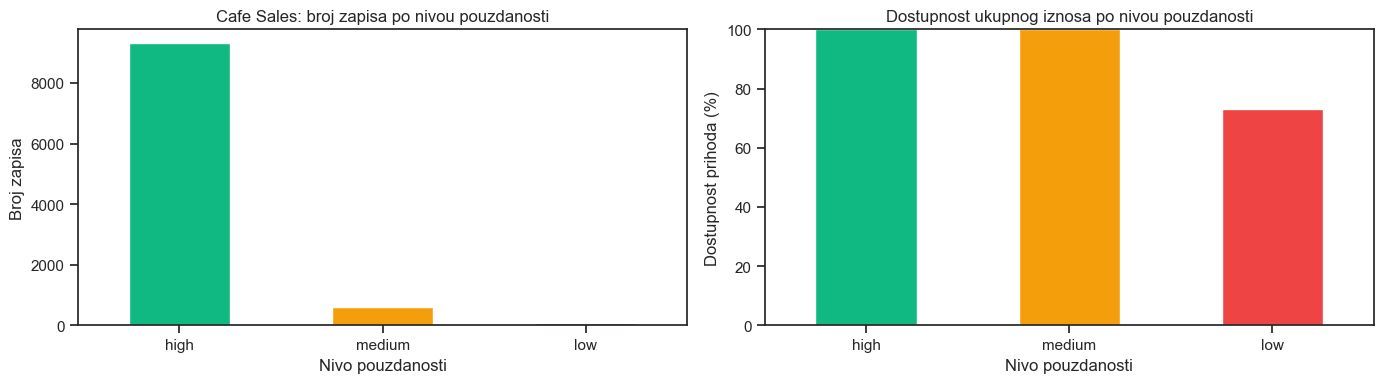

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trust_summary["rows"].plot(kind="bar", ax=axes[0], color=["#10b981", "#f59e0b", "#ef4444"])
axes[0].set_title("Cafe Sales: broj zapisa po nivou pouzdanosti")
axes[0].set_xlabel("Nivo pouzdanosti")
axes[0].set_ylabel("Broj zapisa")
axes[0].tick_params(axis="x", rotation=0)

trust_revenue_table["revenue_available_pct"].plot(kind="bar", ax=axes[1], color=["#10b981", "#f59e0b", "#ef4444"])
axes[1].set_title("Dostupnost ukupnog iznosa po nivou pouzdanosti")
axes[1].set_xlabel("Nivo pouzdanosti")
axes[1].set_ylabel("Dostupnost prihoda (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### Kako se koristi sloj pouzdanosti

Sloj pouzdanosti omogućava da se naredne analize prilagode kvalitetu zapisa. Redovi sa `high` nivoom imaju poznata sva ključna transakciona polja, dok `medium` i `low` nivoi ukazuju na zapise sa delimičnim informacijama.

Oporavljeni redovi se zadržavaju jer su njihove vrednosti izvedene iz pravila. Oznake `recovered_field_count` i `trust_tier` čuvaju informaciju o poreklu podataka, što omogućava transparentnije filtriranje, poređenje i kasnije modeliranje.


## 6. Credit Risk: validacija kvaliteta podataka

Kod `Credit Risk` skupa fokus je drugačiji nego kod `Cafe Sales`. Ovde se kvalitet podataka najpre posmatra kroz validaciju, označavanje i razdvajanje zapisa prema pouzdanosti za analizu i modeliranje.

Validacija se zasniva na tri grupe provera:

- potpunost ključnih atributa,
- logička ograničenja za starost, radni staž i kreditnu istoriju,
- konzistentnost izvedenih odnosa, kao što je odnos iznosa kredita i prihoda.


In [147]:
credit_working = credit_raw.copy()
credit_working["record_id"] = np.arange(len(credit_working))

credit_missing_table = pd.DataFrame({
    "missing": credit_working.isna().sum(),
    "missing_pct": (credit_working.isna().mean() * 100).round(2),
    "unique": credit_working.nunique(dropna=False),
    "dtype": credit_working.dtypes.astype(str),
}).sort_values("missing_pct", ascending=False)

credit_missing_table


,missing,missing_pct,unique,dtype
loan_int_rate,3116,9.56,349,float64
person_emp_length,895,2.75,37,float64
person_age,0,0.00,58,int64
person_income,0,0.00,4295,int64
person_home_ownership,0,0.00,4,str
loan_intent,0,0.00,6,str
loan_grade,0,0.00,7,str
loan_amnt,0,0.00,753,int64
loan_status,0,0.00,2,int64
loan_percent_income,0,0.00,77,float64


In [148]:
def build_credit_quality_flags(frame):
    flags = pd.DataFrame(index=frame.index)

    duplicate_check_frame = frame.drop(columns=["record_id"], errors="ignore")
    flags["duplicate_row"] = duplicate_check_frame.duplicated(keep=False)
    flags["missing_interest_rate"] = frame["loan_int_rate"].isna()
    flags["missing_emp_length"] = frame["person_emp_length"].isna()

    flags["invalid_age"] = frame["person_age"].lt(18) | frame["person_age"].gt(100)
    flags["invalid_income"] = frame["person_income"].le(0)
    flags["invalid_loan_amount"] = frame["loan_amnt"].le(0)
    flags["invalid_emp_length"] = (
        frame["person_emp_length"].notna()
        & (frame["person_emp_length"] > (frame["person_age"] - 14))
    )
    flags["invalid_credit_history_length"] = (
        frame["cb_person_cred_hist_length"].notna()
        & (frame["cb_person_cred_hist_length"] > (frame["person_age"] - 18))
    )

    calculated_ratio = frame["loan_amnt"] / frame["person_income"]
    flags["loan_percent_income_conflict"] = (
        frame["person_income"].gt(0)
        & frame["loan_percent_income"].notna()
        & (calculated_ratio - frame["loan_percent_income"]).abs().gt(0.02)
    )

    return flags


credit_quality_flags = build_credit_quality_flags(credit_working)
credit_issue_summary = pd.DataFrame({
    "affected_rows": credit_quality_flags.sum().sort_values(ascending=False),
})
credit_issue_summary["share_of_dataset_pct"] = (
    credit_issue_summary["affected_rows"] / len(credit_working) * 100
).round(2)

credit_issue_summary


,affected_rows,share_of_dataset_pct
missing_interest_rate,3116,9.56
missing_emp_length,895,2.75
invalid_credit_history_length,781,2.40
duplicate_row,330,1.01
loan_percent_income_conflict,283,0.87
invalid_age,5,0.02
invalid_emp_length,2,0.01
invalid_income,0,0.00
invalid_loan_amount,0,0.00


In [149]:
credit_working["quality_issue_count"] = credit_quality_flags.sum(axis=1)
credit_working["has_quality_issue"] = credit_working["quality_issue_count"] > 0

credit_record_quality = pd.DataFrame({
    "rows": credit_working["quality_issue_count"].value_counts().sort_index(),
})
credit_record_quality["share_of_dataset_pct"] = (
    credit_record_quality["rows"] / len(credit_working) * 100
).round(2)
credit_record_quality.index.name = "quality_issue_count"

credit_record_quality


,rows,share_of_dataset_pct
quality_issue_count,,
0,27438,84.21
1,4879,14.97
2,259,0.79
3,5,0.02


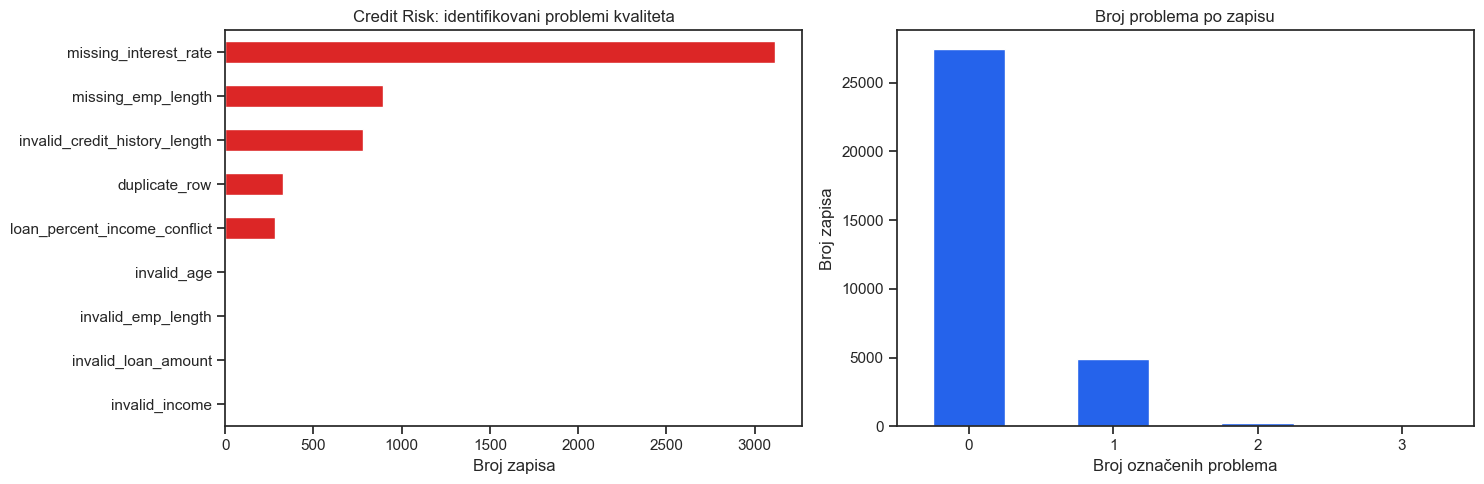

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

credit_issue_summary["affected_rows"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#dc2626",
)
axes[0].set_title("Credit Risk: identifikovani problemi kvaliteta")
axes[0].set_xlabel("Broj zapisa")

credit_record_quality["rows"].plot(
    kind="bar",
    ax=axes[1],
    color="#2563eb",
)
axes[1].set_title("Broj problema po zapisu")
axes[1].set_xlabel("Broj označenih problema")
axes[1].set_ylabel("Broj zapisa")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [151]:
credit_problem_examples = credit_working.loc[
    credit_working["has_quality_issue"],
    [
        "record_id",
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "cb_person_cred_hist_length",
        "quality_issue_count",
    ],
].head(10)

credit_problem_examples


,record_id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,quality_issue_count
0,0,22,59000,123.0,35000,16.02,0.59,3,1
4,4,24,54400,8.0,35000,14.27,0.55,4,1
14,14,23,115000,2.0,35000,7.90,0.30,4,1
17,17,23,92111,7.0,35000,20.25,0.32,4,1
35,35,21,12000,5.0,2500,7.51,0.21,4,1
39,39,23,71500,3.0,30000,NaN,0.42,4,1
40,40,26,62050,6.0,30000,17.99,0.41,2,1
48,48,22,66300,4.0,30000,12.69,0.38,3,1
50,50,24,78000,4.0,30000,NaN,0.38,4,1
57,57,23,277000,3.0,35000,NaN,0.13,4,1


### Nalazi iz Credit Risk validacije

`Credit Risk` skup ima manji procenat nedostajućih vrednosti od `Cafe Sales`, ali problemi koji postoje imaju veći značaj za interpretaciju rizika. Nedostajuća kamatna stopa i radni staž utiču na važne prediktore, dok nelogične vrednosti starosti, radnog staža i kreditne istorije ukazuju na zapise koje treba dodatno kontrolisati.

Ovaj deo uvodi `quality_issue_count` i `has_quality_issue`, čime se problematični zapisi čuvaju u skupu i postaju vidljivi za kasniju obradu, filtriranje i poređenje modelskih rezultata.


## 7. Credit Risk: kontrolisana obrada problematičnih vrednosti

Nakon validacije sledi kontrolisana obrada. Cilj ovog koraka je da se smanji broj tehničkih problema u skupu i da se istovremeno zadrži informacija o zapisima koji su menjani ili označeni kao rizični.

Za razliku od `Cafe Sales` skupa, ovde se većina vrednosti obrađuje kombinacijom uklanjanja duplikata, oprezne imputacije, preračunavanja izvedenog odnosa i zadržavanja indikatora kvaliteta.


In [152]:
credit_processing_decisions = pd.DataFrame([
    {
        "problem": "Duplirani redovi",
        "obrada": "Uklanjaju se ponovljeni redovi, uz zadržavanje prve pojave.",
    },
    {
        "problem": "Nedostajuća kamatna stopa (`loan_int_rate`)",
        "obrada": "Imputira se medianom u okviru iste kreditne klase (`loan_grade`).",
    },
    {
        "problem": "Nedostajući radni staž (`person_emp_length`)",
        "obrada": "Imputira se medianom u okviru starosne grupe.",
    },
    {
        "problem": "Nelogičan radni staž",
        "obrada": "Vrednost se prvo postavlja na missing, zatim ulazi u kontrolisanu imputaciju.",
    },
    {
        "problem": "Konflikt u `loan_percent_income`",
        "obrada": "Odnos se preračunava iz `loan_amnt / person_income` kada je prihod validan.",
    },
    {
        "problem": "Nerealna starost ili kreditna istorija",
        "obrada": "Zapis se označava kao rizičan za kvalitet; vrednost se ne popravlja agresivno.",
    },
])

credit_processing_decisions


,problem,obrada
0,Duplirani redovi,"Uklanjaju se ponovljeni redovi, uz zadržavanje..."
1,Nedostajuća kamatna stopa (`loan_int_rate`),Imputira se medianom u okviru iste kreditne kl...
2,Nedostajući radni staž (`person_emp_length`),Imputira se medianom u okviru starosne grupe.
3,Nelogičan radni staž,"Vrednost se prvo postavlja na missing, zatim u..."
4,Konflikt u `loan_percent_income`,Odnos se preračunava iz `loan_amnt / person_in...
5,Nerealna starost ili kreditna istorija,Zapis se označava kao rizičan za kvalitet; vre...


In [153]:
def credit_processing_scorecard(frame, flags, label):
    return pd.Series({
        "dataset_version": label,
        "rows": len(frame),
        "duplicate_rows": int(flags["duplicate_row"].sum()) if "duplicate_row" in flags else 0,
        "missing_interest_rate": int(frame["loan_int_rate"].isna().sum()),
        "missing_emp_length": int(frame["person_emp_length"].isna().sum()),
        "invalid_age": int(flags["invalid_age"].sum()) if "invalid_age" in flags else 0,
        "invalid_emp_length": int(flags["invalid_emp_length"].sum()) if "invalid_emp_length" in flags else 0,
        "invalid_credit_history_length": int(flags["invalid_credit_history_length"].sum()) if "invalid_credit_history_length" in flags else 0,
        "loan_percent_income_conflict": int(flags["loan_percent_income_conflict"].sum()) if "loan_percent_income_conflict" in flags else 0,
        "rows_with_quality_issue": int(flags.any(axis=1).sum()),
    })


In [154]:
credit_cleaned = credit_working.copy()
credit_cleaned["was_duplicate_removed"] = False
credit_cleaned["was_interest_rate_imputed"] = False
credit_cleaned["was_emp_length_imputed"] = False
credit_cleaned["was_emp_length_invalidated"] = False
credit_cleaned["was_ratio_recalculated"] = False
credit_cleaned["high_risk_quality_record"] = False

# Duplikati se uklanjaju na osnovu originalnih kolona, bez record_id i bez pomoćnih flagova.
credit_original_columns = list(credit_raw.columns)
duplicate_mask = credit_cleaned[credit_original_columns].duplicated(keep="first")
removed_duplicate_rows = int(duplicate_mask.sum())
credit_cleaned = credit_cleaned.loc[~duplicate_mask].copy()

# Ponovna validacija nakon uklanjanja duplikata.
credit_flags_cleaning_stage = build_credit_quality_flags(credit_cleaned)

# Nelogičan radni staž se tretira kao nedostajuća vrednost pre imputacije.
invalid_emp_mask = credit_flags_cleaning_stage["invalid_emp_length"]
credit_cleaned.loc[invalid_emp_mask, "person_emp_length"] = np.nan
credit_cleaned.loc[invalid_emp_mask, "was_emp_length_invalidated"] = True

# Rizični zapisi se označavaju, ali se starost i kreditna istorija ne menjaju agresivno.
high_risk_mask = (
    credit_flags_cleaning_stage["invalid_age"]
    | credit_flags_cleaning_stage["invalid_credit_history_length"]
)
credit_cleaned.loc[high_risk_mask, "high_risk_quality_record"] = True

# Imputacija kamatne stope medianom po kreditnoj klasi.
interest_missing_mask = credit_cleaned["loan_int_rate"].isna()
loan_grade_medians = credit_cleaned.groupby("loan_grade")["loan_int_rate"].transform("median")
global_interest_median = credit_cleaned["loan_int_rate"].median()
credit_cleaned.loc[interest_missing_mask, "loan_int_rate"] = loan_grade_medians[interest_missing_mask].fillna(global_interest_median)
credit_cleaned.loc[interest_missing_mask, "was_interest_rate_imputed"] = True

# Imputacija radnog staža medianom po starosnoj grupi.
age_bins = [17, 25, 35, 45, 55, 65, np.inf]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
credit_cleaned["age_group"] = pd.cut(credit_cleaned["person_age"], bins=age_bins, labels=age_labels)
emp_missing_mask = credit_cleaned["person_emp_length"].isna()
emp_group_medians = credit_cleaned.groupby("age_group", observed=False)["person_emp_length"].transform("median")
global_emp_median = credit_cleaned["person_emp_length"].median()
credit_cleaned.loc[emp_missing_mask, "person_emp_length"] = emp_group_medians[emp_missing_mask].fillna(global_emp_median)
credit_cleaned.loc[emp_missing_mask, "was_emp_length_imputed"] = True

# Preračunavanje izvedenog odnosa kredita i prihoda.
ratio_conflict_mask = (
    credit_cleaned["person_income"].gt(0)
    & (credit_cleaned["loan_amnt"] / credit_cleaned["person_income"] - credit_cleaned["loan_percent_income"]).abs().gt(0.02)
)
credit_cleaned.loc[ratio_conflict_mask, "loan_percent_income"] = (
    credit_cleaned.loc[ratio_conflict_mask, "loan_amnt"] / credit_cleaned.loc[ratio_conflict_mask, "person_income"]
).round(2)
credit_cleaned.loc[ratio_conflict_mask, "was_ratio_recalculated"] = True

credit_cleaned_flags = build_credit_quality_flags(credit_cleaned)
credit_cleaned["quality_issue_count_after_processing"] = credit_cleaned_flags.sum(axis=1)
credit_cleaned["has_quality_issue_after_processing"] = credit_cleaned["quality_issue_count_after_processing"] > 0

removed_duplicate_rows


165

In [155]:
credit_before_score = credit_processing_scorecard(
    credit_working,
    credit_quality_flags,
    "pre obrade",
)
credit_after_score = credit_processing_scorecard(
    credit_cleaned,
    credit_cleaned_flags,
    "posle obrade",
)

credit_processing_comparison = pd.DataFrame([credit_before_score, credit_after_score]).set_index("dataset_version")
credit_processing_comparison


,rows,duplicate_rows,missing_interest_rate,missing_emp_length,invalid_age,invalid_emp_length,invalid_credit_history_length,loan_percent_income_conflict,rows_with_quality_issue
dataset_version,,,,,,,,,
pre obrade,32581,330,3116,895,5,2,781,283,5143
posle obrade,32416,0,0,0,5,0,774,0,779


In [156]:
credit_processing_log = pd.DataFrame({
    "affected_rows": {
        "removed_duplicate_rows": removed_duplicate_rows,
        "interest_rate_imputed": int(credit_cleaned["was_interest_rate_imputed"].sum()),
        "emp_length_invalidated": int(credit_cleaned["was_emp_length_invalidated"].sum()),
        "emp_length_imputed": int(credit_cleaned["was_emp_length_imputed"].sum()),
        "ratio_recalculated": int(credit_cleaned["was_ratio_recalculated"].sum()),
        "high_risk_quality_record": int(credit_cleaned["high_risk_quality_record"].sum()),
    }
})
credit_processing_log["share_of_cleaned_dataset_pct"] = (
    credit_processing_log["affected_rows"] / len(credit_cleaned) * 100
).round(2)

credit_processing_log.sort_values("affected_rows", ascending=False)


,affected_rows,share_of_cleaned_dataset_pct
interest_rate_imputed,3095,9.55
emp_length_imputed,889,2.74
high_risk_quality_record,779,2.40
ratio_recalculated,282,0.87
removed_duplicate_rows,165,0.51
emp_length_invalidated,2,0.01


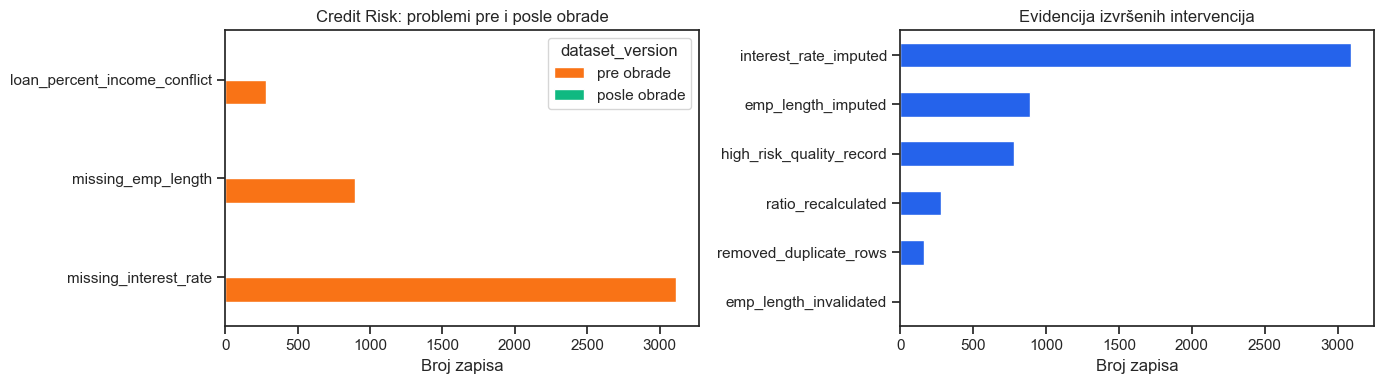

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

credit_processing_comparison[[
    "missing_interest_rate",
    "missing_emp_length",
    "loan_percent_income_conflict",
]].T.plot(kind="barh", ax=axes[0], color=["#f97316", "#10b981"])
axes[0].set_title("Credit Risk: problemi pre i posle obrade")
axes[0].set_xlabel("Broj zapisa")

credit_processing_log["affected_rows"].sort_values().plot(kind="barh", ax=axes[1], color="#2563eb")
axes[1].set_title("Evidencija izvršenih intervencija")
axes[1].set_xlabel("Broj zapisa")

plt.tight_layout()
plt.show()


### Efekat kontrolisane obrade

Ovaj korak smanjuje tehničke probleme u `Credit Risk` skupu i zadržava trag o svakoj intervenciji. Nedostajuće vrednosti se imputiraju uz grupnu osnovu, izvedeni odnos `loan_percent_income` se preračunava iz postojećih kolona, a rizične vrednosti starosti i kreditne istorije ostaju označene.

Na taj način obrađeni skup postaje pogodniji za dalju analizu, uz očuvane informacije o kvalitetu podataka. To je posebno važno zato što kod kreditnog rizika i mala grupa problematičnih zapisa može uticati na interpretaciju modela i procenu rizične klase.


## 8. Credit Risk: kvalitet podataka i odnos sa kreditnim rizikom

Pre modeliranja je važno proveriti da li su problemi kvaliteta povezani sa ciljnom promenljivom. Ako zapisi sa problemima imaju drugačiju stopu rizične klase, njihovo uklanjanje, imputacija ili označavanje može uticati na zaključke modela.

U ovom skupu je ciljna promenljiva `loan_status`, gde vrednost `1` označava rizičan ishod kredita. Zato se u ovom delu poredi stopa rizične klase kod zapisa sa i bez problema kvaliteta.


In [158]:
def default_rate_summary(frame, group_column, target="loan_status"):
    summary = (
        frame
        .groupby(group_column, dropna=False)
        .agg(
            rows=(target, "size"),
            default_count=(target, "sum"),
            default_rate_pct=(target, lambda values: round(values.mean() * 100, 2)),
        )
    )
    summary["share_of_dataset_pct"] = (summary["rows"] / len(frame) * 100).round(2)
    return summary


raw_default_rate = round(credit_working["loan_status"].mean() * 100, 2)
cleaned_default_rate = round(credit_cleaned["loan_status"].mean() * 100, 2)

pd.DataFrame({
    "dataset_version": ["pre obrade", "posle obrade"],
    "rows": [len(credit_working), len(credit_cleaned)],
    "default_rate_pct": [raw_default_rate, cleaned_default_rate],
    "default_count": [int(credit_working["loan_status"].sum()), int(credit_cleaned["loan_status"].sum())],
})


,dataset_version,rows,default_rate_pct,default_count
0,pre obrade,32581,21.82,7108
1,posle obrade,32416,21.87,7089


In [159]:
credit_quality_target_summary = default_rate_summary(
    credit_working,
    "has_quality_issue",
)
credit_quality_target_summary.index = credit_quality_target_summary.index.map({False: "bez označenih problema", True: "sa označenim problemima"})
credit_quality_target_summary


,rows,default_count,default_rate_pct,share_of_dataset_pct
has_quality_issue,,,,
bez označenih problema,27438,5752,20.96,84.21
sa označenim problemima,5143,1356,26.37,15.79


In [160]:
overall_default_rate = credit_working["loan_status"].mean() * 100

issue_target_rows = []
for flag_name in credit_quality_flags.columns:
    mask = credit_quality_flags[flag_name]
    if mask.sum() == 0:
        continue
    subset = credit_working.loc[mask]
    default_rate = subset["loan_status"].mean() * 100
    issue_target_rows.append({
        "quality_flag": flag_name,
        "rows": int(mask.sum()),
        "share_of_dataset_pct": round(mask.mean() * 100, 2),
        "default_rate_pct": round(default_rate, 2),
        "default_rate_diff_pct_points": round(default_rate - overall_default_rate, 2),
    })

issue_target_summary = (
    pd.DataFrame(issue_target_rows)
    .sort_values("default_rate_diff_pct_points", ascending=False)
    .reset_index(drop=True)
)

issue_target_summary


,quality_flag,rows,share_of_dataset_pct,default_rate_pct,default_rate_diff_pct_points
0,loan_percent_income_conflict,283,0.87,100.00,78.18
1,invalid_emp_length,2,0.01,50.00,28.18
2,missing_emp_length,895,2.75,31.51,9.69
3,invalid_credit_history_length,781,2.40,24.20,2.38
4,missing_interest_rate,3116,9.56,20.67,-1.15
5,duplicate_row,330,1.01,11.52,-10.30
6,invalid_age,5,0.02,0.00,-21.82


In [161]:
cleaned_quality_target_summary = default_rate_summary(
    credit_cleaned,
    "has_quality_issue_after_processing",
)
cleaned_quality_target_summary.index = cleaned_quality_target_summary.index.map({False: "bez preostalih problema", True: "sa preostalim problemima"})

high_risk_target_summary = default_rate_summary(
    credit_cleaned,
    "high_risk_quality_record",
)
high_risk_target_summary.index = high_risk_target_summary.index.map({False: "standardni zapisi", True: "rizični po kvalitetu"})

display(cleaned_quality_target_summary)
display(high_risk_target_summary)


,rows,default_count,default_rate_pct,share_of_dataset_pct
has_quality_issue_after_processing,,,,
bez preostalih problema,31637,6901,21.81,97.6
sa preostalim problemima,779,188,24.13,2.4


,rows,default_count,default_rate_pct,share_of_dataset_pct
high_risk_quality_record,,,,
standardni zapisi,31637,6901,21.81,97.6
rizični po kvalitetu,779,188,24.13,2.4


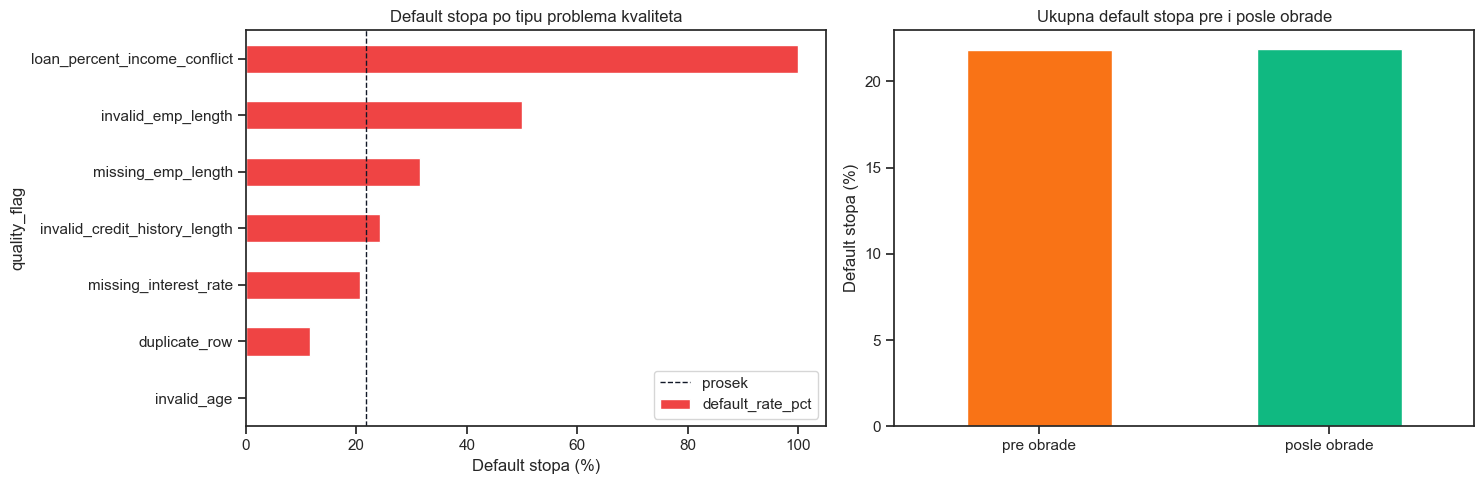

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

issue_target_summary.set_index("quality_flag")["default_rate_pct"].sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#ef4444",
)
axes[0].axvline(overall_default_rate, color="#111827", linestyle="--", linewidth=1, label="prosek")
axes[0].set_title("Default stopa po tipu problema kvaliteta")
axes[0].set_xlabel("Default stopa (%)")
axes[0].legend()

pd.Series({
    "pre obrade": raw_default_rate,
    "posle obrade": cleaned_default_rate,
}).plot(kind="bar", ax=axes[1], color=["#f97316", "#10b981"])
axes[1].set_title("Ukupna default stopa pre i posle obrade")
axes[1].set_ylabel("Default stopa (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### Veza sa modeliranjem

Analiza pokazuje da problemi kvaliteta imaju odnos sa ciljnom promenljivom. Kada određeni tipovi problema imaju drugačiju stopu rizične klase, obrada tih zapisa može promeniti raspodelu targeta i ponašanje modela.

Zbog toga se u nastavku koriste obrađeni podaci zajedno sa indikatorima kvaliteta. Oni omogućavaju da se kasnije proveri da li model dobija stabilnije ulaze nakon obrade i da li informacije o kvalitetu zapisa same po sebi nose signal za procenu rizika.


## 9. Poređenje obrađenih skupova i priprema za modelski eksperiment

Nakon oporavka i kontrolisane obrade prikazuje se šta kvalitetniji skupovi omogućavaju u analizi. Ovaj deo je ciljano poređenje posledica prethodnih koraka.

Kod `Cafe Sales` posmatra se poslovna analiza nad oporavljenim transakcionim vrednostima i nivoima pouzdanosti. Kod `Credit Risk` posmatra se raspodela rizične klase nakon obrade i odnos rizika sa kreditnom klasom i flagovima kvaliteta.


In [163]:
cafe_analysis_frame = cafe_recovered[cafe_recovered["trust_tier"].isin(["high", "medium"])].copy()

revenue_by_item = (
    cafe_analysis_frame
    .dropna(subset=["Item", "Total_num"])
    .groupby("Item")
    .agg(
        transactions=("Transaction ID", "size"),
        total_revenue=("Total_num", "sum"),
        median_transaction_value=("Total_num", "median"),
    )
    .sort_values("total_revenue", ascending=False)
)

revenue_by_item


,transactions,total_revenue,median_transaction_value
Item,,,
Salad,1268,19001.0,15.0
Sandwich,1127,13719.2,12.0
Smoothie,1094,13373.2,12.0
Juice,1168,10478.4,9.0
Cake,1138,10402.2,9.0
Coffee,1279,7741.3,6.0
Tea,1198,5406.2,4.5
Cookie,1207,3572.7,3.0


In [164]:
cafe_trust_business_summary = (
    cafe_recovered
    .groupby("trust_tier")
    .agg(
        rows=("Transaction ID", "size"),
        total_revenue=("Total_num", "sum"),
        revenue_available_pct=("revenue_available", lambda values: round(values.mean() * 100, 2)),
        recovered_rows=("any_field_recovered", "sum"),
    )
    .reindex(["high", "medium", "low"])
)
cafe_trust_business_summary["share_of_rows_pct"] = (
    cafe_trust_business_summary["rows"] / len(cafe_recovered) * 100
).round(2)

cafe_trust_business_summary


,rows,total_revenue,revenue_available_pct,recovered_rows,share_of_rows_pct
trust_tier,,,,,
high,9304,82313.7,100.00,1572,93.04
medium,611,6032.0,100.00,58,6.11
low,85,612.0,72.94,0,0.85


In [165]:
credit_grade_risk = (
    credit_cleaned
    .groupby("loan_grade")
    .agg(
        rows=("loan_status", "size"),
        default_rate_pct=("loan_status", lambda values: round(values.mean() * 100, 2)),
        high_risk_quality_rows=("high_risk_quality_record", "sum"),
    )
)
credit_grade_risk["high_risk_quality_pct"] = (
    credit_grade_risk["high_risk_quality_rows"] / credit_grade_risk["rows"] * 100
).round(2)

credit_grade_risk


,rows,default_rate_pct,high_risk_quality_rows,high_risk_quality_pct
loan_grade,,,,
A,10703,9.96,244,2.28
B,10387,16.32,268,2.58
C,6438,20.75,152,2.36
D,3620,59.06,97,2.68
E,963,64.49,13,1.35
F,241,70.54,3,1.24
G,64,98.44,2,3.12


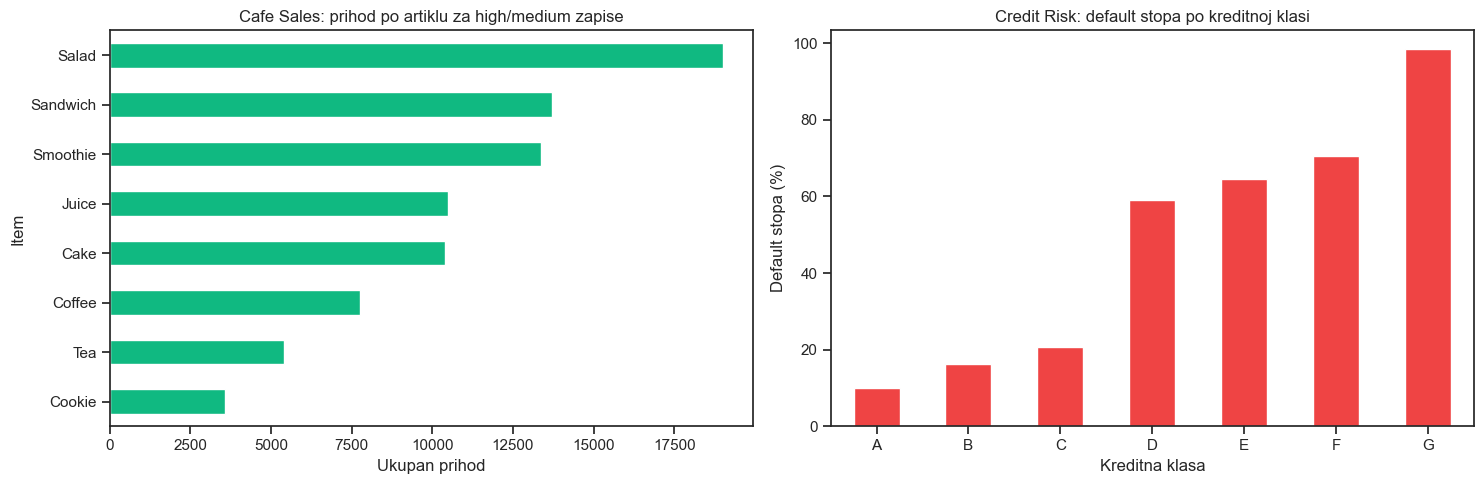

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

revenue_by_item["total_revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#10b981")
axes[0].set_title("Cafe Sales: prihod po artiklu za high/medium zapise")
axes[0].set_xlabel("Ukupan prihod")

credit_grade_risk["default_rate_pct"].plot(kind="bar", ax=axes[1], color="#ef4444")
axes[1].set_title("Credit Risk: default stopa po kreditnoj klasi")
axes[1].set_xlabel("Kreditna klasa")
axes[1].set_ylabel("Default stopa (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [167]:
approach_comparison = pd.DataFrame([
    {
        "dataset": "Cafe Sales",
        "problem": "Oštećene transakcione vrednosti",
        "pristup": "Rule-based oporavak pomoću cenovnika i aritmetičkih pravila",
        "rezultat": "Veća upotrebljivost kolona Item, Quantity, Price i Total",
    },
    {
        "dataset": "Cafe Sales",
        "problem": "Zapisi nisu jednako pouzdani posle oporavka",
        "pristup": "Sloj pouzdanosti zapisa (`trust_tier`)",
        "rezultat": "Analize se mogu ograničiti na high/medium zapise",
    },
    {
        "dataset": "Credit Risk",
        "problem": "Missing i nelogične vrednosti",
        "pristup": "Kontrolisana imputacija, preračunavanje i quality flags",
        "rezultat": "Smanjen broj tehničkih problema uz zadržavanje tragova obrade",
    },
    {
        "dataset": "Credit Risk",
        "problem": "Kvalitet podataka povezan je sa targetom",
        "pristup": "Analiza default stope po tipu problema kvaliteta",
        "rezultat": "Quality flags imaju interpretativnu vrednost za procenu rizika",
    },
])

approach_comparison


,dataset,problem,pristup,rezultat
0,Cafe Sales,Oštećene transakcione vrednosti,Rule-based oporavak pomoću cenovnika i aritmet...,"Veća upotrebljivost kolona Item, Quantity, Pri..."
1,Cafe Sales,Zapisi nisu jednako pouzdani posle oporavka,Sloj pouzdanosti zapisa (`trust_tier`),Analize se mogu ograničiti na high/medium zapise
2,Credit Risk,Missing i nelogične vrednosti,"Kontrolisana imputacija, preračunavanje i qual...",Smanjen broj tehničkih problema uz zadržavanje...
3,Credit Risk,Kvalitet podataka povezan je sa targetom,Analiza default stope po tipu problema kvaliteta,Quality flags imaju interpretativnu vrednost z...


### Priprema za modelski deo

Ova sekcija povezuje obradu podataka sa narednim korakom. Kod `Cafe Sales` oporavak omogućava pouzdaniju analizu prihoda i formiranje regresionog zadatka za prognozu dnevne potražnje po artiklu. Kod `Credit Risk` kontrolisana obrada smanjuje tehničke probleme, dok flagovi kvaliteta ostaju kao informacija koja može uticati na predikciju rizične klase.

Modelski eksperiment se zato posmatra kao provera efekta kvaliteta podataka.


## 10. Cafe Sales: regresioni eksperiment za dnevnu potražnju po artiklu

Za `Cafe Sales` se kao glavni modelski zadatak koristi predikcija dnevne potražnje po artiklu. Ovaj zadatak je prirodniji za transakcioni skup od klasifikacije pojedinačnih redova, jer oporavak `Item`, `Quantity` i `Transaction Date` direktno utiče na dnevne agregate koji ulaze u model.

Ciljna promenljiva je `quantity_sold`, odnosno ukupan broj prodatih komada određenog artikla određenog dana. Kao referentni target koristi se agregat iz oporavljenih pouzdanih zapisa, dok se porede feature-i izvedeni iz tri verzije podataka:

- `initial`: agregati iz inicijalno parsiranih podataka,
- `recovered`: agregati nakon rule-based oporavka,
- `trusted_recovered`: agregati nakon oporavka uz korišćenje samo `high` i `medium` zapisa.

Na ovaj način se meri da li oporavak podataka daje bolju osnovu za prognozu iste referentne potražnje.


In [168]:
def build_daily_item_demand(frame, dataset_label, trust_filter=None):
    df = frame.copy()
    if trust_filter is not None:
        df = df[df["trust_tier"].isin(trust_filter)].copy()

    demand_base = df.dropna(subset=["TransactionDate_dt", "Item", "Quantity_num"]).copy()
    demand_base["date"] = demand_base["TransactionDate_dt"].dt.date
    demand_base["is_modified"] = demand_base["Receipt Modifier"].fillna("none").ne("none").astype(int)

    aggregated = (
        demand_base
        .groupby(["date", "Item"])
        .agg(
            quantity_sold=("Quantity_num", "sum"),
            observed_transactions=("Transaction ID", "size"),
            avg_price=("Price_num", "median"),
            modifier_share=("is_modified", "mean"),
        )
        .reset_index()
    )

    aggregated["date"] = pd.to_datetime(aggregated["date"])
    aggregated["weekday"] = aggregated["date"].dt.day_name()
    aggregated["month"] = aggregated["date"].dt.month
    aggregated["is_weekend"] = aggregated["date"].dt.dayofweek.isin([5, 6]).astype(int)
    aggregated["dataset_version"] = dataset_label

    aggregated = aggregated.sort_values(["Item", "date"]).reset_index(drop=True)
    aggregated["quantity_lag_1"] = aggregated.groupby("Item")["quantity_sold"].shift(1)
    aggregated["quantity_rolling_mean_3"] = (
        aggregated
        .groupby("Item")["quantity_sold"]
        .shift(1)
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    return aggregated.dropna(subset=["quantity_lag_1", "quantity_rolling_mean_3"]).reset_index(drop=True)


initial_demand = build_daily_item_demand(cafe_typed, "initial")
recovered_demand = build_daily_item_demand(cafe_recovered, "recovered")
trusted_recovered_demand = build_daily_item_demand(
    cafe_recovered,
    "trusted_recovered",
    trust_filter=["high", "medium"],
)

pd.DataFrame({
    "dataset_version": ["initial", "recovered", "trusted_recovered"],
    "daily_item_rows": [len(initial_demand), len(recovered_demand), len(trusted_recovered_demand)],
    "total_quantity_in_aggregates": [
        initial_demand["quantity_sold"].sum(),
        recovered_demand["quantity_sold"].sum(),
        trusted_recovered_demand["quantity_sold"].sum(),
    ],
    "avg_daily_item_quantity": [
        round(initial_demand["quantity_sold"].mean(), 2),
        round(recovered_demand["quantity_sold"].mean(), 2),
        round(trusted_recovered_demand["quantity_sold"].mean(), 2),
    ],
})


,dataset_version,daily_item_rows,total_quantity_in_aggregates,avg_daily_item_quantity
0,initial,2761,24813.0,8.99
1,recovered,2787,26772.0,9.61
2,trusted_recovered,2787,26772.0,9.61


In [169]:
reference_demand = trusted_recovered_demand[["date", "Item", "quantity_sold"]].rename(
    columns={"quantity_sold": "reference_quantity_sold"}
)

demand_common_keys = (
    initial_demand[["date", "Item"]]
    .merge(recovered_demand[["date", "Item"]], on=["date", "Item"])
    .merge(reference_demand[["date", "Item"]], on=["date", "Item"])
)

initial_demand_model = (
    initial_demand
    .merge(demand_common_keys, on=["date", "Item"])
    .merge(reference_demand, on=["date", "Item"])
)
recovered_demand_model = (
    recovered_demand
    .merge(demand_common_keys, on=["date", "Item"])
    .merge(reference_demand, on=["date", "Item"])
)
trusted_demand_model = (
    trusted_recovered_demand
    .merge(demand_common_keys, on=["date", "Item"])
    .merge(reference_demand, on=["date", "Item"])
)

# Ista vremenska podela za sve verzije: poslednjih 25% datuma koristi se kao test skup.
unique_dates = np.array(sorted(demand_common_keys["date"].unique()))
split_position = int(len(unique_dates) * 0.75)
train_dates = set(unique_dates[:split_position])
test_dates = set(unique_dates[split_position:])

pd.DataFrame({
    "dataset_version": ["initial", "recovered", "trusted_recovered"],
    "model_rows": [len(initial_demand_model), len(recovered_demand_model), len(trusted_demand_model)],
    "train_rows": [
        initial_demand_model["date"].isin(train_dates).sum(),
        recovered_demand_model["date"].isin(train_dates).sum(),
        trusted_demand_model["date"].isin(train_dates).sum(),
    ],
    "test_rows": [
        initial_demand_model["date"].isin(test_dates).sum(),
        recovered_demand_model["date"].isin(test_dates).sum(),
        trusted_demand_model["date"].isin(test_dates).sum(),
    ],
    "target_source": ["trusted_recovered", "trusted_recovered", "trusted_recovered"],
})


,dataset_version,model_rows,train_rows,test_rows,target_source
0,initial,2761,2070,691,trusted_recovered
1,recovered,2761,2070,691,trusted_recovered
2,trusted_recovered,2761,2070,691,trusted_recovered


In [170]:
demand_feature_cols = [
    "Item",
    "weekday",
    "month",
    "is_weekend",
    "avg_price",
    "modifier_share",
    "quantity_lag_1",
    "quantity_rolling_mean_3",
]
demand_numeric_features = [
    "month",
    "is_weekend",
    "avg_price",
    "modifier_share",
    "quantity_lag_1",
    "quantity_rolling_mean_3",
]
demand_categorical_features = ["Item", "weekday"]

demand_model_configs = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=350,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=350,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=-1,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    ),
}


def build_demand_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), demand_numeric_features),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]),
                demand_categorical_features,
            ),
        ],
        sparse_threshold=0.0,
    )


def run_demand_experiment(frame, dataset_label, model_name, regressor):
    train = frame[frame["date"].isin(train_dates)].copy()
    test = frame[frame["date"].isin(test_dates)].copy()

    X_train = train[demand_feature_cols].copy()
    X_test = test[demand_feature_cols].copy()
    y_train = train["reference_quantity_sold"]
    y_test = test["reference_quantity_sold"]

    model = Pipeline([
        ("preprocessor", build_demand_preprocessor()),
        ("regressor", clone(regressor)),
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, pred) ** 0.5
    return {
        "model": model_name,
        "dataset_version": dataset_label,
        "rows": len(frame),
        "train_rows": len(train),
        "test_rows": len(test),
        "mae": round(mean_absolute_error(y_test, pred), 4),
        "rmse": round(rmse, 4),
        "r2": round(r2_score(y_test, pred), 4),
    }


In [171]:
demand_experiment_versions = [
    ("initial", initial_demand_model),
    ("recovered", recovered_demand_model),
    ("trusted_recovered", trusted_demand_model),
]

demand_model_results = []
for dataset_label, frame in demand_experiment_versions:
    for model_name, regressor in demand_model_configs.items():
        demand_model_results.append(
            run_demand_experiment(frame, dataset_label, model_name, regressor)
        )

demand_model_summary = (
    pd.DataFrame(demand_model_results)
    .set_index(["model", "dataset_version"])
    .sort_index()
)

demand_model_summary


rows  train_rows  test_rows     mae    rmse      r2
model                dataset_version                                                       
CatBoost             initial            2761        2070        691  3.6328  4.7162  0.3371
                     recovered          2761        2070        691  3.3571  4.4221  0.4172
                     trusted_recovered  2761        2070        691  3.3571  4.4221  0.4172
ExtraTrees           initial            2761        2070        691  3.8007  4.9282  0.2762
                     recovered          2761        2070        691  3.3810  4.5183  0.3916
                     trusted_recovered  2761        2070        691  3.3810  4.5183  0.3916
HistGradientBoosting initial            2761        2070        691  3.7417  4.8494  0.2992
                     recovered          2761        2070        691  3.4640  4.5164  0.3921
                     trusted_recovered  2761        2070        691  3.4640  4.5164  0.3921
LightGBM             initial            2761        2070        691  3.7635  4.8733  0.2922
                     recovered          2761        2070        691  3.5046  4.5599  0.3803
                     trusted_recovered  2761        2070        691  3.5046  4.5599  0.3803
RandomForest         initial            2761        2070        691  3.6653  4.7079  0.3394
                     recovered          2761        2070        691  3.3619  4.4193  0.4180
                     trusted_recovered  2761        2070        691  3.3619  4.4193  0.4180
Ridge                initial            2761        2070        691  4.5700  5.8270 -0.0119
                     recovered          2761        2070        691  4.5672  5.8214 -0.0100
                     trusted_recovered  2761        2070        691  4.5672  5.8214 -0.0100
XGBoost              initial            2761        2070        691  4.0291  5.0903  0.2278
                     recovered          2761        2070        691  3.5356  4.6276  0.3618
                     trusted_recovered  2761        2070        691  3.5356  4.6276  0.3618

In [172]:
demand_mae_pivot = demand_model_summary.reset_index().pivot(
    index="model",
    columns="dataset_version",
    values="mae",
)
demand_mae_pivot["recovery_mae_delta"] = (
    demand_mae_pivot["recovered"] - demand_mae_pivot["initial"]
).round(4)
demand_mae_pivot["trusted_mae_delta"] = (
    demand_mae_pivot["trusted_recovered"] - demand_mae_pivot["recovered"]
).round(4)

demand_mae_pivot.sort_values("trusted_recovered")


dataset_version,initial,recovered,trusted_recovered,recovery_mae_delta,trusted_mae_delta
model,,,,,
CatBoost,3.6328,3.3571,3.3571,-0.2757,0.0
RandomForest,3.6653,3.3619,3.3619,-0.3034,0.0
ExtraTrees,3.8007,3.3810,3.3810,-0.4197,0.0
HistGradientBoosting,3.7417,3.4640,3.4640,-0.2777,0.0
LightGBM,3.7635,3.5046,3.5046,-0.2589,0.0
XGBoost,4.0291,3.5356,3.5356,-0.4935,0.0
Ridge,4.5700,4.5672,4.5672,-0.0028,0.0


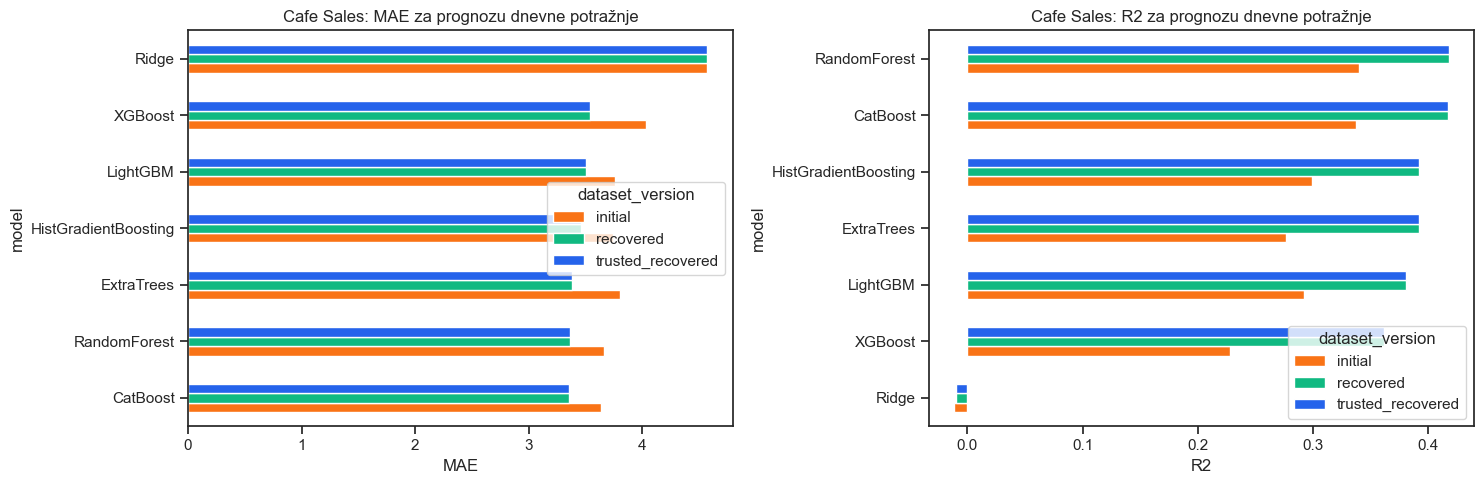

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

demand_mae_pivot[["initial", "recovered", "trusted_recovered"]].sort_values(
    "trusted_recovered"
).plot(kind="barh", ax=axes[0], color=["#f97316", "#10b981", "#2563eb"])
axes[0].set_title("Cafe Sales: MAE za prognozu dnevne potražnje")
axes[0].set_xlabel("MAE")

r2_pivot = demand_model_summary.reset_index().pivot(
    index="model",
    columns="dataset_version",
    values="r2",
)
r2_pivot[["initial", "recovered", "trusted_recovered"]].sort_values(
    "trusted_recovered"
).plot(kind="barh", ax=axes[1], color=["#f97316", "#10b981", "#2563eb"])
axes[1].set_title("Cafe Sales: R2 za prognozu dnevne potražnje")
axes[1].set_xlabel("R2")

plt.tight_layout()
plt.show()


### Tumačenje eksperimenta potražnje

Ovaj eksperiment posmatra `Cafe Sales` kao poslovni problem prognoze potražnje. Umesto klasifikacije pojedinačnih transakcija, model predviđa dnevnu količinu prodatih komada po artiklu. Time se direktno koristi ono što je unapređeno u data-quality delu: oporavljeni artikli, količine i datumi.

Sve verzije se porede prema istom referentnom targetu iz oporavljenih pouzdanih agregata. Razlika u rezultatima zato pokazuje koliko feature-i izvedeni iz inicijalnih ili oporavljenih podataka pomažu u predikciji iste procenjene potražnje.

Ovaj zadatak ima praktičnu interpretaciju: kvalitetniji transakcioni podaci daju pouzdaniju osnovu za planiranje potražnje i zaliha.


## 11. Credit Risk: modelski eksperiment nad inicijalnim i obrađenim podacima

U ovom eksperimentu se proverava kako kontrolisana obrada i indikatori kvaliteta utiču na klasifikaciju kreditnog rizika. Ciljna promenljiva je `loan_status`, gde vrednost `1` označava rizičan ishod.

Porede se tri verzije istih zadržanih zapisa:

- `raw_baseline`: inicijalne vrednosti, uz osnovnu imputaciju u pipeline-u,
- `cleaned`: obrađene vrednosti nakon uklanjanja duplikata, imputacije i preračunavanja odnosa,
- `cleaned_quality_flags`: obrađene vrednosti uz dodatne indikatore kvaliteta i intervencija.

Za sve verzije koristi se ista train-test podela. Time se razlika u rezultatima vezuje za kvalitet i reprezentaciju podataka.


In [174]:
credit_model_base_features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length",
]

credit_quality_features = credit_model_base_features + [
    "was_interest_rate_imputed",
    "was_emp_length_imputed",
    "was_emp_length_invalidated",
    "was_ratio_recalculated",
    "high_risk_quality_record",
    "quality_issue_count_after_processing",
]

credit_numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]
credit_categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
]

credit_quality_numeric_features = credit_numeric_features + ["quality_issue_count_after_processing"]
credit_quality_categorical_features = credit_categorical_features + [
    "was_interest_rate_imputed",
    "was_emp_length_imputed",
    "was_emp_length_invalidated",
    "was_ratio_recalculated",
    "high_risk_quality_record",
]


In [175]:
retained_credit_ids = credit_cleaned["record_id"].copy()

credit_raw_model_data = credit_working[credit_working["record_id"].isin(retained_credit_ids)].copy()
credit_cleaned_model_data = credit_cleaned.copy()
credit_quality_model_data = credit_cleaned.copy()

credit_split_frame = credit_cleaned_model_data[["record_id", "loan_status"]].drop_duplicates()
credit_train_ids, credit_test_ids = train_test_split(
    credit_split_frame["record_id"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=credit_split_frame["loan_status"],
)

pd.DataFrame({
    "dataset_version": ["raw_baseline", "cleaned", "cleaned_quality_flags"],
    "rows": [len(credit_raw_model_data), len(credit_cleaned_model_data), len(credit_quality_model_data)],
    "default_rate_pct": [
        round(credit_raw_model_data["loan_status"].mean() * 100, 2),
        round(credit_cleaned_model_data["loan_status"].mean() * 100, 2),
        round(credit_quality_model_data["loan_status"].mean() * 100, 2),
    ],
})


,dataset_version,rows,default_rate_pct
0,raw_baseline,32416,21.87
1,cleaned,32416,21.87
2,cleaned_quality_flags,32416,21.87


In [176]:
credit_model_configs = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=350,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=350,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    ),
}


def build_credit_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True))]),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ],
        sparse_threshold=0.0,
    )


def credit_effective_completeness(frame, feature_cols):
    return round((1 - frame[feature_cols].isna().mean().mean()) * 100, 2)


def run_credit_risk_experiment(frame, dataset_label, feature_cols, numeric_features, categorical_features, model_name, classifier):
    train = frame[frame["record_id"].isin(credit_train_ids)].copy()
    test = frame[frame["record_id"].isin(credit_test_ids)].copy()

    model = Pipeline(
        steps=[
            ("preprocessor", build_credit_preprocessor(numeric_features, categorical_features)),
            ("classifier", clone(classifier)),
        ]
    )

    X_train = train[feature_cols].copy()
    X_test = test[feature_cols].copy()
    for column in categorical_features:
        X_train[column] = X_train[column].astype("object")
        X_test[column] = X_test[column].astype("object")
    y_train = train["loan_status"].astype(int)
    y_test = test["loan_status"].astype(int)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model.named_steps["classifier"], "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        roc_auc = round(roc_auc_score(y_test, proba), 4)
    else:
        roc_auc = np.nan

    report = pd.DataFrame(
        classification_report(
            y_test,
            pred,
            labels=[0, 1],
            target_names=["non_default", "default"],
            output_dict=True,
            zero_division=0,
        )
    ).T.round(3)

    return {
        "model": model_name,
        "dataset_version": dataset_label,
        "rows": len(frame),
        "effective_feature_completeness_pct": credit_effective_completeness(frame, feature_cols),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_test, pred), 4),
        "macro_f1": round(f1_score(y_test, pred, average="macro"), 4),
        "default_precision": report.loc["default", "precision"],
        "default_recall": report.loc["default", "recall"],
        "default_f1": report.loc["default", "f1-score"],
        "roc_auc": roc_auc,
        "report": report,
    }


In [177]:
credit_experiment_versions = [
    {
        "label": "raw_baseline",
        "frame": credit_raw_model_data,
        "feature_cols": credit_model_base_features,
        "numeric_features": credit_numeric_features,
        "categorical_features": credit_categorical_features,
    },
    {
        "label": "cleaned",
        "frame": credit_cleaned_model_data,
        "feature_cols": credit_model_base_features,
        "numeric_features": credit_numeric_features,
        "categorical_features": credit_categorical_features,
    },
    {
        "label": "cleaned_quality_flags",
        "frame": credit_quality_model_data,
        "feature_cols": credit_quality_features,
        "numeric_features": credit_quality_numeric_features,
        "categorical_features": credit_quality_categorical_features,
    },
]

credit_model_results = []
for version in credit_experiment_versions:
    for model_name, classifier in credit_model_configs.items():
        credit_model_results.append(
            run_credit_risk_experiment(
                frame=version["frame"],
                dataset_label=version["label"],
                feature_cols=version["feature_cols"],
                numeric_features=version["numeric_features"],
                categorical_features=version["categorical_features"],
                model_name=model_name,
                classifier=classifier,
            )
        )

credit_model_summary = (
    pd.DataFrame(credit_model_results)
    .drop(columns=["report"])
    .set_index(["model", "dataset_version"])
    .sort_index()
)

credit_model_summary


rows  effective_feature_completeness_pct  accuracy  balanced_accuracy  macro_f1  \
model                dataset_version                                                                                           
CatBoost             cleaned                32416                              100.00    0.9381             0.8630    0.8996   
                     cleaned_quality_flags  32416                              100.00    0.9390             0.8655    0.9014   
                     raw_baseline           32416                               98.88    0.9372             0.8617    0.8982   
ExtraTrees           cleaned                32416                              100.00    0.8981             0.8376    0.8467   
                     cleaned_quality_flags  32416                              100.00    0.8949             0.8342    0.8423   
                     raw_baseline           32416                               98.88    0.8950             0.8334    0.8422   
HistGradientBoosting cleaned                32416                              100.00    0.9385             0.8666    0.9011   
                     cleaned_quality_flags  32416                              100.00    0.9392             0.8680    0.9022   
                     raw_baseline           32416                               98.88    0.9374             0.8653    0.8994   
LightGBM             cleaned                32416                              100.00    0.9389             0.8678    0.9018   
                     cleaned_quality_flags  32416                              100.00    0.9403             0.8699    0.9040   
                     raw_baseline           32416                               98.88    0.9387             0.8667    0.9012   
LogisticRegression   cleaned                32416                              100.00    0.7825             0.7785    0.7287   
                     cleaned_quality_flags  32416                              100.00    0.7839             0.7762    0.7289   
                     raw_baseline           32416                               98.88    0.7721             0.7745    0.7199   
RandomForest         cleaned                32416                              100.00    0.9337             0.8611    0.8937   
                     cleaned_quality_flags  32416                              100.00    0.9340             0.8635    0.8946   
                     raw_baseline           32416                               98.88    0.9327             0.8600    0.8922   
XGBoost              cleaned                32416                              100.00    0.9378             0.8651    0.8998   
                     cleaned_quality_flags  32416                              100.00    0.9389             0.8668    0.9016   
                     raw_baseline           32416                               98.88    0.9369             0.8625    0.8981   

                                            default_precision  default_recall  default_f1  roc_auc  
model                dataset_version                                                                
CatBoost             cleaned                            0.983           0.730       0.837   0.9385  
                     cleaned_quality_flags              0.982           0.735       0.841   0.9400  
                     raw_baseline                       0.980           0.727       0.835   0.9379  
ExtraTrees           cleaned                            0.788           0.730       0.758   0.9080  
                     cleaned_quality_flags              0.778           0.726       0.751   0.9090  
                     raw_baseline                       0.780           0.724       0.751   0.9072  
HistGradientBoosting cleaned                            0.974           0.739       0.840   0.9475  
                     cleaned_quality_flags              0.974           0.742       0.842   0.9485  
                     raw_baseline                       0.970           0.737       0.837 

In [178]:
credit_metric_pivot = credit_model_summary.reset_index().pivot(
    index="model",
    columns="dataset_version",
    values="default_f1",
)
credit_metric_pivot["cleaning_gain"] = (
    credit_metric_pivot["cleaned"] - credit_metric_pivot["raw_baseline"]
).round(4)
credit_metric_pivot["quality_flag_gain"] = (
    credit_metric_pivot["cleaned_quality_flags"] - credit_metric_pivot["cleaned"]
).round(4)

credit_metric_pivot.sort_values("cleaned_quality_flags", ascending=False)


dataset_version,cleaned,cleaned_quality_flags,raw_baseline,cleaning_gain,quality_flag_gain
model,,,,,
LightGBM,0.841,0.845,0.840,0.001,0.004
HistGradientBoosting,0.840,0.842,0.837,0.003,0.002
CatBoost,0.837,0.841,0.835,0.002,0.004
XGBoost,0.838,0.841,0.835,0.003,0.003
RandomForest,0.828,0.830,0.826,0.002,0.002
ExtraTrees,0.758,0.751,0.751,0.007,-0.007
LogisticRegression,0.608,0.607,0.599,0.009,-0.001


In [179]:
best_credit_model_name = credit_metric_pivot["cleaned_quality_flags"].idxmax()

best_credit_reports = {
    result["dataset_version"]: result["report"]
    for result in credit_model_results
    if result["model"] == best_credit_model_name
}

print("Najbolji model nad obrađenim podacima sa quality flagovima:", best_credit_model_name)
display(
    pd.concat(best_credit_reports, axis=1).loc[["non_default", "default", "accuracy", "macro avg"]]
)


Najbolji model nad obrađenim podacima sa quality flagovima: LightGBM


raw_baseline                             cleaned                           cleaned_quality_flags                         
               precision recall f1-score   support precision recall f1-score   support             precision recall f1-score  support
non_default        0.932  0.995    0.962  6332.000     0.932  0.994    0.962  6332.000                 0.933  0.995    0.963  6332.00
default            0.975  0.739    0.840  1772.000     0.973  0.742    0.841  1772.000                 0.976  0.745    0.845  1772.00
accuracy           0.939  0.939    0.939     0.939     0.939  0.939    0.939     0.939                 0.940  0.940    0.940     0.94
macro avg          0.953  0.867    0.901  8104.000     0.952  0.868    0.902  8104.000                 0.955  0.870    0.904  8104.00

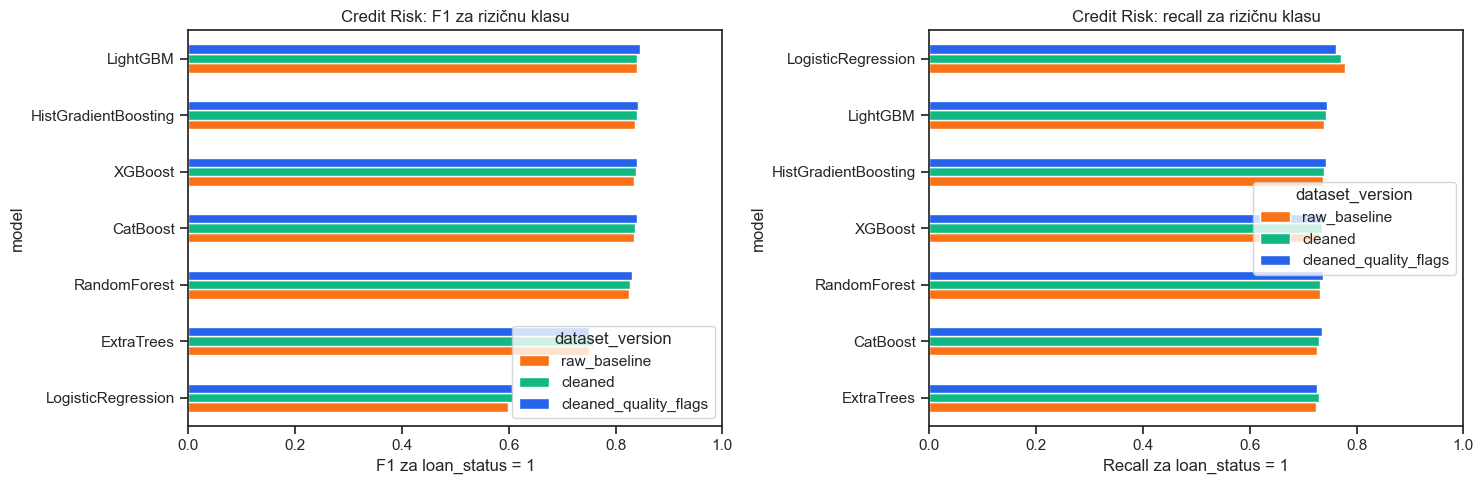

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

credit_metric_pivot[["raw_baseline", "cleaned", "cleaned_quality_flags"]].sort_values(
    "cleaned_quality_flags"
).plot(kind="barh", ax=axes[0], color=["#f97316", "#10b981", "#2563eb"])
axes[0].set_title("Credit Risk: F1 za rizičnu klasu")
axes[0].set_xlabel("F1 za loan_status = 1")
axes[0].set_xlim(0, 1)

default_recall_pivot = credit_model_summary.reset_index().pivot(
    index="model",
    columns="dataset_version",
    values="default_recall",
)
default_recall_pivot[["raw_baseline", "cleaned", "cleaned_quality_flags"]].sort_values(
    "cleaned_quality_flags"
).plot(kind="barh", ax=axes[1], color=["#f97316", "#10b981", "#2563eb"])
axes[1].set_title("Credit Risk: recall za rizičnu klasu")
axes[1].set_xlabel("Recall za loan_status = 1")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Tumačenje Credit Risk eksperimenta

Ovaj eksperiment pokazuje kako se obrada kvaliteta podataka odražava na klasifikaciju rizične klase. Posebno su važne metrike za `loan_status = 1`, jer ta klasa predstavlja kreditni rizik koji model treba da prepozna.

Poređenje `raw_baseline`, `cleaned` i `cleaned_quality_flags` verzije pokazuje da se efekat obrade može meriti kroz promenu odziva, F1 mere i balansirane tačnosti. Quality flagovi se posmatraju kao dodatni signal o pouzdanosti zapisa i o intervencijama koje su primenjene tokom obrade.


## 12. Poređenje pristupa po datasetu

Dva dataseta prikazuju različite scenarije kvaliteta podataka. `Cafe Sales` je primer u kome postoje domenska i aritmetička pravila za oporavak dela vrednosti. `Credit Risk` je primer u kome se veći deo obrade zasniva na validaciji, kontrolisanoj imputaciji i čuvanju indikatora kvaliteta.

Zbog toga se efekat kvaliteta podataka ne meri samo jednom metrikom. Posmatraju se kompletnost, upotrebljivost, transparentnost intervencija i promena rezultata modela.


In [181]:
final_approach_summary = pd.DataFrame([
    {
        "dataset": "Cafe Sales",
        "problem": "Oštećene transakcione vrednosti (`Item`, `Quantity`, `Price`, `Total`)",
        "pristup": "Rule-based oporavak pomoću cenovnika, faktora izmene računa i aritmetičkih pravila",
        "efekat_na_podatke": "Veća upotrebljivost ključnih transakcionih kolona i evidencija svake izmene kroz `repair_log`",
        "efekat_na_model": "Niži MAE u regresiji dnevne potražnje po artiklu kod većine modela",
        "ograničenje": "Oporavak zavisi od stabilnosti cenovnika i jasno definisanih odnosa u podacima",
    },
    {
        "dataset": "Cafe Sales",
        "problem": "Zapisi imaju različit nivo pouzdanosti posle oporavka",
        "pristup": "Uvođenje `trust_tier`, `known_core_fields` i recovery flagova",
        "efekat_na_podatke": "Analize se mogu ograničiti na pouzdanije zapise ili porediti po nivou poverenja",
        "efekat_na_model": "Regresioni agregati se grade nad inicijalnom, oporavljenom i pouzdanom verzijom podataka",
        "ograničenje": "Pouzdanost je definisana pravilima projekta i zavisi od izabranih pragova",
    },
    {
        "dataset": "Credit Risk",
        "problem": "Nedostajuće vrednosti, duplikati i nelogične vrednosti",
        "pristup": "Uklanjanje duplikata, grupna imputacija, preračunavanje odnosa i quality flags",
        "efekat_na_podatke": "Broj zapisa sa označenim problemima smanjen je sa 5143 na 779",
        "efekat_na_model": "Blago poboljšanje F1 mere za rizičnu klasu kod više modela",
        "ograničenje": "Baseline modeli su već jaki, pa je prostor za veliki skok metrika ograničen",
    },
    {
        "dataset": "Credit Risk",
        "problem": "Problemi kvaliteta imaju odnos sa ciljnom promenljivom",
        "pristup": "Analiza default stope po tipu quality problema i čuvanje indikatora kvaliteta",
        "efekat_na_podatke": "Problematični zapisi ostaju vidljivi umesto da budu prikriveni obradom",
        "efekat_na_model": "Quality flagovi daju dodatni signal o pouzdanosti zapisa i intervencijama",
        "ograničenje": "Veza quality flagova i targeta je deskriptivna i ne dokazuje uzročnost",
    },
])

final_approach_summary


,dataset,problem,pristup,efekat_na_podatke,efekat_na_model,ograničenje
0,Cafe Sales,"Oštećene transakcione vrednosti (`Item`, `Quan...","Rule-based oporavak pomoću cenovnika, faktora ...",Veća upotrebljivost ključnih transakcionih kol...,Niži MAE u regresiji dnevne potražnje po artik...,Oporavak zavisi od stabilnosti cenovnika i jas...
1,Cafe Sales,Zapisi imaju različit nivo pouzdanosti posle o...,"Uvođenje `trust_tier`, `known_core_fields` i r...",Analize se mogu ograničiti na pouzdanije zapis...,"Regresioni agregati se grade nad inicijalnom, ...",Pouzdanost je definisana pravilima projekta i ...
2,Credit Risk,"Nedostajuće vrednosti, duplikati i nelogične v...","Uklanjanje duplikata, grupna imputacija, prera...",Broj zapisa sa označenim problemima smanjen je...,Blago poboljšanje F1 mere za rizičnu klasu kod...,"Baseline modeli su već jaki, pa je prostor za ..."
3,Credit Risk,Problemi kvaliteta imaju odnos sa ciljnom prom...,Analiza default stope po tipu quality problema...,Problematični zapisi ostaju vidljivi umesto da...,Quality flagovi daju dodatni signal o pouzdano...,Veza quality flagova i targeta je deskriptivna...


## 13. Završna diskusija

Rad pokazuje da kvalitet podataka ima različite oblike u zavisnosti od strukture dataseta. Kod `Cafe Sales` centralni problem je bio oporavak oštećenih transakcionih vrednosti. Pošto postoje jasni odnosi između artikla, količine, cene, ukupnog iznosa i izmene računa, deo podataka je mogao da se rekonstruiše pomoću pravila.

Kod `Credit Risk` centralni problem je bio drugačiji. Vrednosti se uglavnom obrađuju kroz validaciju, označavanje i kontrolisanu imputaciju. Umesto agresivnog popravljanja svih sumnjivih vrednosti, uvedeni su indikatori kvaliteta koji čuvaju informaciju o tome šta je bilo problematično i koja intervencija je primenjena.

Modelski eksperimenti služe kao praktična provera efekta obrade. Kod `Cafe Sales` oporavljeni agregati daju bolju osnovu za prognozu dnevne potražnje po artiklu. Kod `Credit Risk` kontrolisana obrada i quality flagovi daju manje, ali stabilno poboljšanje u prepoznavanju rizične klase.


### Ograničenja rada

Rezultati treba da se tumače u kontekstu ograničenja oba skupa podataka.

Kod `Cafe Sales` oporavak zavisi od stabilnosti cenovnika i pravilne interpretacije `Receipt Modifier` kolone. Ako bi se cenovnik menjao kroz vreme ili ako bi postojale dodatne poslovne akcije koje nisu zabeležene u podacima, pravila bi morala da se dopune.

Kod `Credit Risk` modeli već u početnoj verziji postižu dobre rezultate, pa obrada kvaliteta ne dovodi do dramatičnog skoka metrika. Vrednost obrade se vidi kroz transparentnost, smanjenje tehničkih problema i čuvanje indikatora kvaliteta, a ne samo kroz veliku promenu jedne metrike.

Dodatno, analiza odnosa quality flagova i targeta je deskriptivna. Ona pokazuje da problemi kvaliteta mogu biti povezani sa rizičnom klasom, ali ne dokazuje uzročno-posledičnu vezu.


### Zaključak

Kvalitet podataka u ovom radu nije posmatran kao jednokratno čišćenje pre modeliranja, već kao proces koji obuhvata audit, validaciju, oporavak, označavanje i proveru efekta na analizu. Dva dataseta zajedno pokazuju da kvalitet podataka može imati različite praktične posledice: kod transakcionih podataka utiče na poslovne agregate i prognozu potražnje, dok kod kreditnog rizika utiče na pouzdanost zapisa, interpretaciju targeta i stabilnost modela.

Glavni rezultat rada je metodološki: kvalitet podataka treba učiniti vidljivim kroz tabele, flagove, logove intervencija i poređenja verzija podataka. Tek nakon toga modelske metrike dobijaju ispravan kontekst.
